In [2]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scipy.stats import chi2_contingency, shapiro
from itertools import combinations

from sklearn.feature_selection import mutual_info_classif


from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, LabelEncoder

from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import fbeta_score, make_scorer, precision_score, recall_score, f1_score


from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import shap

# On utilise imblearn pour le pipeline et le SMOTE
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from imblearn.pipeline import Pipeline as ImbPipeline
import joblib

# **Les Fonctions uilisées pour la partie EDA**

In [3]:
######################################################
################## Partie Univariéé ##################
######################################################


def Diagnostique_quanti(data):
    # 1. On ne garde que les colonnes numériques pour le diagnostic quanti
    data_numeric = data.select_dtypes(include=['number'])

    # 2. On crée le tableau de base (transposé)
    tableau = data_numeric.describe().round(2).T

    # 3. On ajoute les colonnes vides pour le Top Valeur
    tableau['top_val'] = None
    tableau['top_pct'] = None

    # 4. On remplit les stats pour chaque colonne numérique
    for col in data_numeric.columns:
        count_data = data[col].value_counts(normalize=True)   # Classe deja par ordre décroissant
        # On utilise .at[ligne, colonne] pour insérer les valeurs
        tableau.at[col, 'top_val'] = count_data.index[0]
        tableau.at[col, 'top_pct'] = (count_data.values[0] * 100).round(2)

    return tableau



def tracer_boxplots(data):
    # On sélectionne les colonnes numériques du dataset passé en paramètre
    colonnes = data.select_dtypes(include=["number"]).columns
    
    # 1. On prépare la grille (Ta logique : 3 colonnes)
    plt.figure(figsize=(15, 10)) 

    for i, col in enumerate(colonnes):
        # Ta logique de calcul d'index pour les sous-graphiques
        plt.subplot(len(colonnes) // 3 + 1, 3, i + 1)
        
        # 2. On dessine le boxplot sur les données du paramètre 'data'
        sns.boxplot(x=data[col], color="skyblue")
        plt.title(col)

    # 3. On espace et on affiche
    plt.tight_layout()
    plt.show()



def diagnostiquer_qualitatives(df):
    """
    Analyse automatique des variables catégorielles d'un DataFrame.

    Cette fonction permet de détecter :
    1. La cardinalité (nombre de modalités uniques).
    2. La présence de valeurs manquantes.
    3. La domination d'une catégorie (concentration).
    4. Les erreurs de saisie (via l'affichage détaillé).
    """

    # 1. Sélection automatique des colonnes de type 'object' ou 'category'
    va_quali = df.select_dtypes(include=['object', 'category','string'])
    

    if va_quali.empty:
        return "Aucune variable qualitative trouvée."

    print("=== DÉTAIL DES FRÉQUENCES PAR VARIABLE ===")
    for col in va_quali.columns:
        print(df[col].value_counts())
        print()

    print("\n" + "="*40)
    print("=== TABLEAU SYNTHÉTIQUE DE SANTÉ DES DONNÉES ===")

    # 2. Génération des statistiques descriptives
    stat = va_quali.describe(include='all').round(2).T

    # 3. Ajout d'indicateurs pour le nettoyage
    # Pourcentage de présence de la valeur dominante
    stat['top_%'] = round((stat['freq'] / stat['count']) * 100, 2)
    # Taux de valeurs manquantes
    stat['null_rate_%'] = round((1 - (stat['count'] / len(df))) * 100, 2)

    # On réorganise les colonnes pour la lisibilité
    colonnes_finales = ['count', 'unique', 'top', 'top_%', 'null_rate_%']

    return stat[colonnes_finales].sort_values(by='unique', ascending=False)


######################################################
################## Partie Bivariée ##################
######################################################

def correlations_fortes(data, seuil=0.7, methode="pearson"):
    """
    Calcule les corrélations fortes entre variables numériques.
    - garde uniquement le numérique
    - ignore les colonnes constantes
    - retourne un tableau trié
    """

    if methode not in ["pearson", "spearman"]:
        raise ValueError("La méthode doit être 'pearson' ou 'spearman'")

    # garder uniquement le numérique
    data_num = data.select_dtypes(include='number')
    data_num = data_num.loc[:, data_num.nunique() > 1]

    # matrice de corrélation
    corr = data_num.corr(method=methode)
    corr.index.name = 'Var1'

    # 🔹 format long
    df_long = corr.reset_index().melt(
        id_vars='Var1',
        var_name='Var2',
        value_name='Corrélation'
    )

    # paires uniques
    df_uniques = df_long[df_long['Var1'] < df_long['Var2']].copy()

    # force absolue + filtrage
    df_uniques['Force_Absolue'] = df_uniques['Corrélation'].abs()
    df_filtre = df_uniques[df_uniques['Force_Absolue'] >= seuil]

    # tri
    df_resultat = df_filtre.sort_values(by='Force_Absolue', ascending=False)

    print(f"{len(df_resultat)} corrélations fortes trouvées (|r| ≥ {seuil})")

    return df_resultat.reset_index(drop=True)




# --- FONCTION V DE CRAMER ---
def cramers_v_corrected(contingency_table):
    """
    Calcule le V de Cramer avec correction de biais (basée sur la formule de Bergsma)
    pour une meilleure rigueur académique.
    """
    # 1. Calcul des statistiques initiales
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, c = contingency_table.shape

    # 2. Correction du biais du Khi-deux
    chi2_corr = max(0, chi2 - (r - 1) * (c - 1) / (n - 1))

    # Correction des degrés de liberté (dimension minimale)
    min_dim = min(r, c)
    min_dim_corr = min_dim - ((r - 1) * (c - 1) / (n - 1)) / (min_dim - 1)

    # Gestion des bords (pour les cas extrêmes ou dimension 1)
    if min_dim <= 1 or min_dim_corr <= 0:
        return np.nan

    # 3. Calcul du V de Cramer corrigé
    return np.sqrt(chi2_corr / (n * min_dim_corr))



def analyser_associations_quali(df):
    """
    Fonction finale : Calcule le Khi-deux et V de Cramer pour toutes les paires
    de variables qualitatives et retourne un DataFrame trié.
    """
    variables = df.columns.to_list()
    resultats = []

    for var1, var2 in combinations(variables, 2):
        # Création du tableau de contingence
        contingency_table = pd.crosstab(df[var1], df[var2])

        # Test Khi-deux
        chi2, p_value, dof, _ = chi2_contingency(contingency_table)

        # V de Cramer
        v_cramer = cramers_v_corrected(contingency_table)

        resultats.append({
            'Variable 1': var1,
            'Variable 2': var2,
            'p-value': p_value,
            'Chi2': chi2,
            'V_Cramer': v_cramer
        })

    # Création du DataFrame et tri
    df_res = pd.DataFrame(resultats)
    df_res = df_res.sort_values(by='V_Cramer', ascending=False).reset_index(drop=True)

    return df_res

# **Import des données**

In [4]:
print(os.listdir("data notebook"))

['extrait_eval.csv', 'extrait_sirh.csv', 'extrait_sondage.csv']


In [5]:
# Pour charger le fichier d'évaluation
df_eval = pd.read_csv("data notebook/extrait_eval.csv")

# Pour charger le fichier SIRH
df_sirh = pd.read_csv("data notebook/extrait_sirh.csv")

# Pour charger le sondage
df_sondage = pd.read_csv("data notebook/extrait_sondage.csv")

# **Nettoyage et Préparation des Données**

L'objectif est de garantir l'intégrité des données avant l'analyse.
- [ ] **Valeurs manquantes :** Identification et traitement (imputation ou suppression).
- [ ] **Erreurs lexicales :** Uniformisation des types `Object` (casse, espaces, fautes de frappe).
- [ ] **Formatage :** Conversion des types (dates, numériques) et respect des standards.
- [ ] **Doublons :** Identification et suppression des entrées répétées.
- [ ] **Outliers :** Détection des valeurs extrêmes via méthodes statistiques ou graphiques.

## **Fichier `Evaluation de performances & ressenti`**

- Données liées au travaille et au management
   - Lignes : Un employé par ligne.
   - Colonnes : Scores de satisfaction et notes de performance.
   - Clé : `eval_number.`

In [6]:
print( df_eval.info(), '\n' )

## Vérification de doublons en fonction de la clé qui est cencé representé une un employé
nb_doublons = df_eval['eval_number'].duplicated(keep=False).sum()
print(f"Il y a {nb_doublons} doublons.", '\n' )

display(df_eval.head(3) )


<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   satisfaction_employee_environnement        1470 non-null   int64
 1   note_evaluation_precedente                 1470 non-null   int64
 2   niveau_hierarchique_poste                  1470 non-null   int64
 3   satisfaction_employee_nature_travail       1470 non-null   int64
 4   satisfaction_employee_equipe               1470 non-null   int64
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64
 6   eval_number                                1470 non-null   str  
 7   note_evaluation_actuelle                   1470 non-null   int64
 8   heure_supplementaires                      1470 non-null   str  
 9   augementation_salaire_precedente           1470 non-null   str  
dtypes: int64(7), str(3)
memory usage: 115.0 KB
None 

Il y a 0 

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,2,3,2,4,1,1,E_1,3,Oui,11 %
1,3,2,2,2,4,3,E_2,4,Non,23 %
2,4,2,1,3,2,3,E_4,3,Oui,15 %


- On consate pour ce data chaque variable contient des lignes complete donc aucune valeur manquante

- On constate des **erreurs de formatage** pour les variables:      
    - `augementation_salaire_precedente`:  suppression du '%'
    - `eval_number` : suppression du 'E_'

In [7]:
##############################################################"
############ augementation_salaire_precedente ################
##############################################################"

# 1. Nettoyage : suppression du '%', conversion en nombre et transformation en ratio (ex: 0.05)
df_eval["augementation_salaire_precedente"] = df_eval["augementation_salaire_precedente"].str.replace("%", "").astype(float) / 100

# 2. Renommage de la colonne pour plus de clarté
df_eval = df_eval.rename(columns={"augementation_salaire_precedente": "augmentation_precedente_salaire_pct"})


################################################
################# eval_number ##################
################################################

# 1. Nettoyage : suppression du 'E_'
# df_eval['eval_number'].apply(lambda x: int(x.replace("E_", "")))
df_eval['eval_number'] = df_eval['eval_number'].apply(lambda x: x.replace("E_", "")).astype(int)



#######################
#### Vérification #####
#######################

print(df_eval['eval_number'].dtypes)
df_eval[['eval_number', "augmentation_precedente_salaire_pct"]].head(3)


int64


,eval_number,augmentation_precedente_salaire_pct
0,1,0.11
1,2,0.23
2,4,0.15


In [8]:
################################################################
############# Voir les variables qualitatives ##################
################################################################

report = diagnostiquer_qualitatives(df_eval)
display(report)

=== DÉTAIL DES FRÉQUENCES PAR VARIABLE ===
heure_supplementaires
Non    1054
Oui     416
Name: count, dtype: int64


=== TABLEAU SYNTHÉTIQUE DE SANTÉ DES DONNÉES ===


,count,unique,top,top_%,null_rate_%
heure_supplementaires,1470,2,Non,71.7,0.0


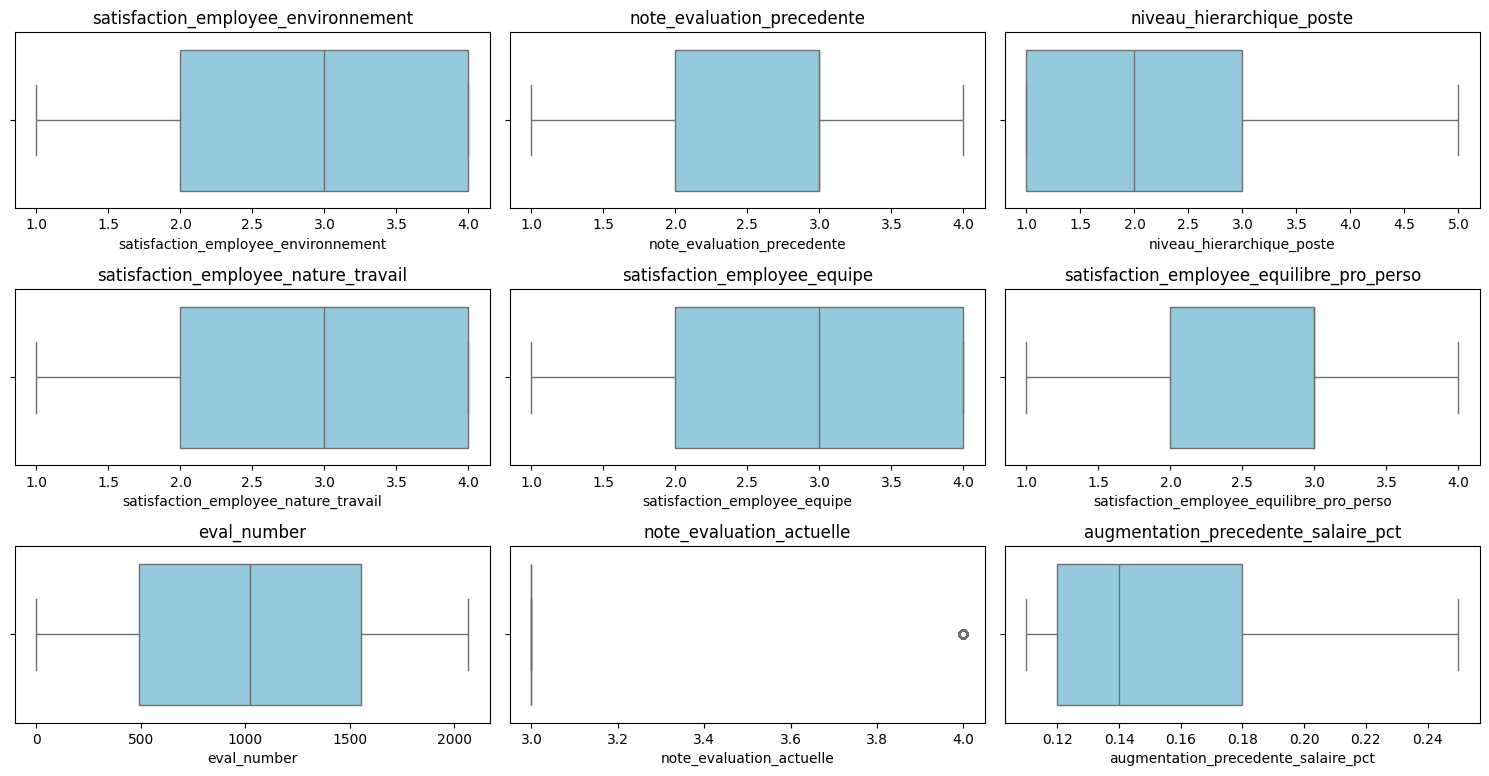

,count,mean,std,min,25%,50%,75%,max,top_val,top_pct
satisfaction_employee_environnement,1470.0,2.72,1.09,1.00,2.00,3.00,4.00,4.00,3,30.82
note_evaluation_precedente,1470.0,2.73,0.71,1.00,2.00,3.00,3.00,4.00,3,59.05
niveau_hierarchique_poste,1470.0,2.06,1.11,1.00,1.00,2.00,3.00,5.00,1,36.94
satisfaction_employee_nature_travail,1470.0,2.73,1.10,1.00,2.00,3.00,4.00,4.00,4,31.22
satisfaction_employee_equipe,1470.0,2.71,1.08,1.00,2.00,3.00,4.00,4.00,3,31.22
satisfaction_employee_equilibre_pro_perso,1470.0,2.76,0.71,1.00,2.00,3.00,3.00,4.00,3,60.75
eval_number,1470.0,1024.87,602.02,1.00,491.25,1020.50,1555.75,2068.00,1,0.07
note_evaluation_actuelle,1470.0,3.15,0.36,3.00,3.00,3.00,3.00,4.00,3,84.63
augmentation_precedente_salaire_pct,1470.0,0.15,0.04,0.11,0.12,0.14,0.18,0.25,0.11,14.29


In [9]:
################################################################
############# Voir les variables quantitatives #################
################################################################


tracer_boxplots(df_eval)
Diagnostique_quanti(df_eval)

> **Globalement, le climat social semble stable (moyenne de satisfaction à 2.7/4) mais l'analyse révèle des signaux faibles critiques sur la rétention.**
> * **Le Point Critique :** **28% des employés** effectuent des heures supplémentaires.
> * **Le Risque Invisible :** Malgré une satisfaction globale correcte, l'écart-type de **1.1** montre une forte disparité. Une partie des effectifs est en zone de "désengagement profond" (notes de 1 ou 2).
> * **Le Biais d'Évaluation :** Avec **84% des employés** notés à 3/4, le système d'évaluation actuel ne permet pas de distinguer efficacement les talents à haute performance des profils moyens.
> * **Le Levier Salarial :** L'augmentation la plus fréquente est de **11%** (inférieure à la moyenne de 15%), ce qui peut créer un sentiment d'iniquité interne.
>

# **Fichier `Identité`**

- Données Administratives/demographique
   - Lignes : Un employé par ligne.
   - Colonnes : Salaire, âge, ancienneté.
   - Clé primaire : `id_employee` . Colonne de réference qui permet d'identifier qui est qui


<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   id_employee                     1470 non-null   int64
 1   age                             1470 non-null   int64
 2   genre                           1470 non-null   str  
 3   revenu_mensuel                  1470 non-null   int64
 4   statut_marital                  1470 non-null   str  
 5   departement                     1470 non-null   str  
 6   poste                           1470 non-null   str  
 7   nombre_experiences_precedentes  1470 non-null   int64
 8   nombre_heures_travailless       1470 non-null   int64
 9   annee_experience_totale         1470 non-null   int64
 10  annees_dans_l_entreprise        1470 non-null   int64
 11  annees_dans_le_poste_actuel     1470 non-null   int64
dtypes: int64(8), str(4)
memory usage: 137.9 KB
None 



,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0


0 

=== DÉTAIL DES FRÉQUENCES PAR VARIABLE ===
genre
M    882
F    588
Name: count, dtype: int64

statut_marital
Marié(e)       673
Célibataire    470
Divorcé(e)     327
Name: count, dtype: int64

departement
Consulting             961
Commercial             446
Ressources Humaines     63
Name: count, dtype: int64

poste
Cadre Commercial           326
Assistant de Direction     292
Consultant                 259
Tech Lead                  145
Manager                    131
Senior Manager             102
Représentant Commercial     83
Directeur Technique         80
Ressources Humaines         52
Name: count, dtype: int64


=== TABLEAU SYNTHÉTIQUE DE SANTÉ DES DONNÉES ===


,count,unique,top,top_%,null_rate_%
poste,1470,9,Cadre Commercial,22.18,0.0
statut_marital,1470,3,Marié(e),45.78,0.0
departement,1470,3,Consulting,65.37,0.0
genre,1470,2,M,60.0,0.0


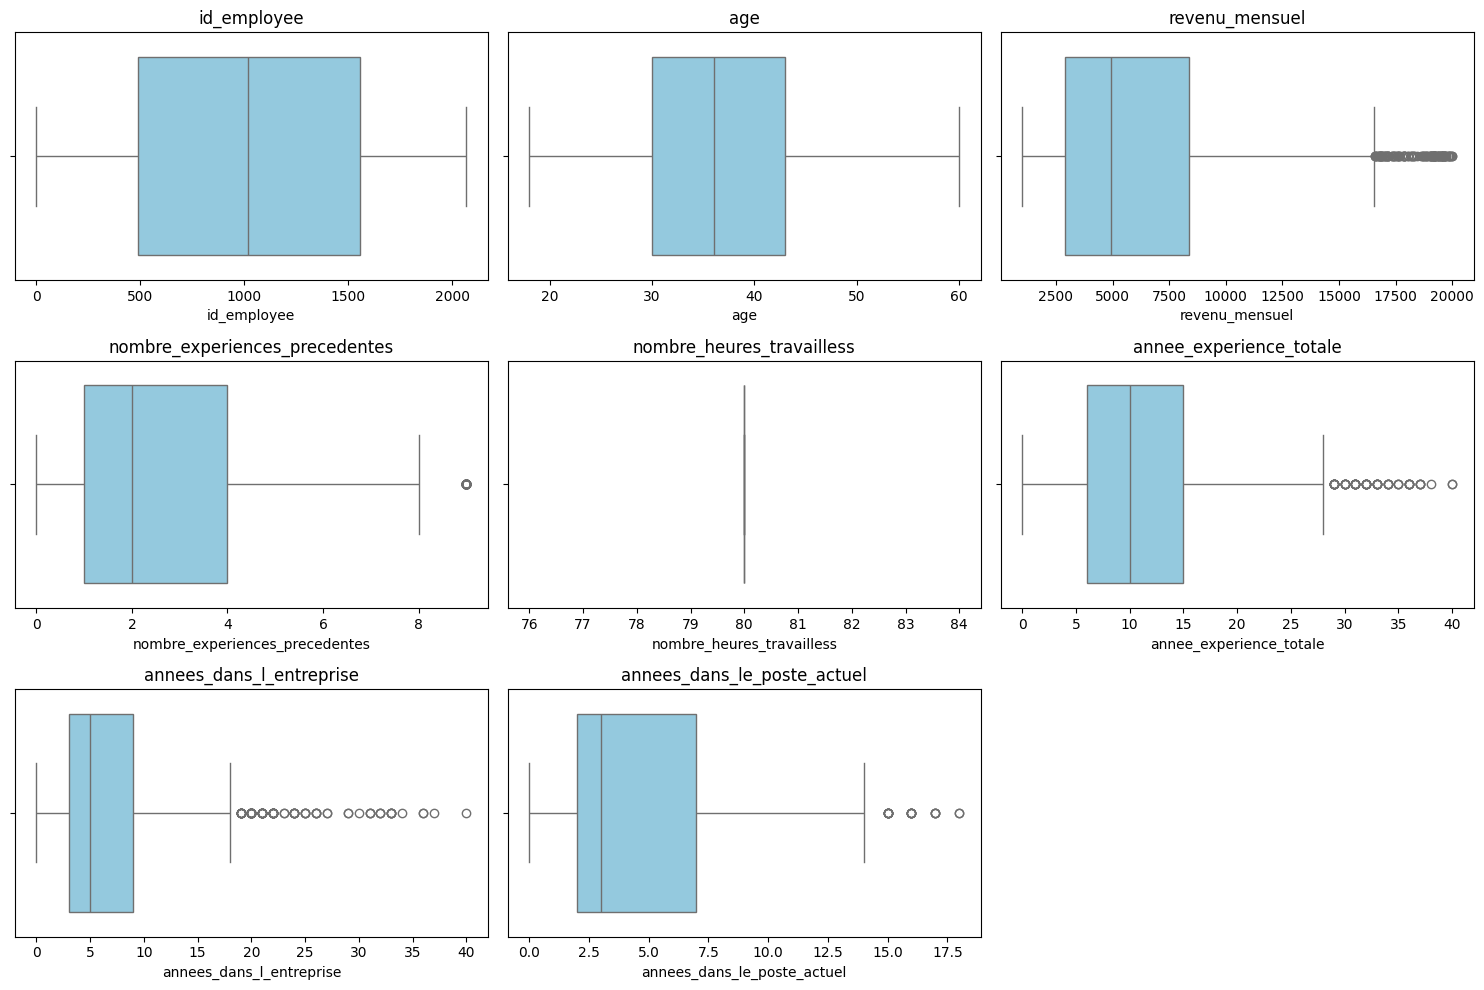

,count,mean,std,min,25%,50%,75%,max,top_val,top_pct
id_employee,1470.0,1024.87,602.02,1.0,491.25,1020.5,1555.75,2068.0,1,0.07
age,1470.0,36.92,9.14,18.0,30.00,36.0,43.00,60.0,35,5.31
revenu_mensuel,1470.0,6502.93,4707.96,1009.0,2911.00,4919.0,8379.00,19999.0,2342,0.27
nombre_experiences_precedentes,1470.0,2.69,2.50,0.0,1.00,2.0,4.00,9.0,1,35.44
nombre_heures_travailless,1470.0,80.00,0.00,80.0,80.00,80.0,80.00,80.0,80,100.0
annee_experience_totale,1470.0,11.28,7.78,0.0,6.00,10.0,15.00,40.0,10,13.74
annees_dans_l_entreprise,1470.0,7.01,6.13,0.0,3.00,5.0,9.00,40.0,5,13.33
annees_dans_le_poste_actuel,1470.0,4.23,3.62,0.0,2.00,3.0,7.00,18.0,2,25.31


In [10]:
print(df_sirh.info(), '\n')
display(df_sirh.head(3))

# Vérifie s'il y a des doublons dans les identifiants employés et affiche le total
print( df_sirh['id_employee'].duplicated().sum(), "\n" )

# Génère et affiche le diagnostic univariée pour les colonnes catégorielles
display( diagnostiquer_qualitatives(df_sirh) )
print()

tracer_boxplots(df_sirh)
display( Diagnostique_quanti(df_sirh) )   # pour les colonnes numériques


#### 1. Variable à écarter : `nombre_heures_travailless`

* **Constat :** L'écart-type () est de **0.00**. Tous les employés affichent exactement 80 heures.`std` = 0.00. Le `min`, la `médiane` et le `max` sont tous à **80.0**.
* **Action :** Cette variable étant une constante, elle n'apporte aucun pouvoir prédictif. Elle sera **supprimée** lors du nettoyage pour alléger le modèle.

#### 2. Variables de Durée : Présence de valeurs extrêmes

* *Variables : `annees_dans_l_entreprise`, `annee_experience_totale`, `annees_dans_le_poste_actuel`.*
* **Constat :** On observe une **asymétrie positive** (skewness). Alors que 75% des employés ont moins de 9 ans d'ancienneté, le maximum atteint 40 ans.
* **Insight :** Le "profil type" chez TechNova est relativement jeune. Les quelques "vétérans" constituent des **outliers** qui pourraient avoir des comportements de démission très différents.

#### 3. Segmentation par le Revenu : `revenu_mensuel`

* **Constat :** La **variance** est très élevée ( de 4707 pour une moyenne de 6502).
* **Insight :** Le salaire est une variable "clivante". Cette forte dispersion est une excellente nouvelle pour le modèle : elle permettra de segmenter efficacement les profils (ex: stagiaires vs top managers).

#### 4. Homogénéité de l'Âge

* **Constat :** Moyenne (36.9)  Médiane (36.0).
* **Insight :** La distribution de l'âge est **équilibrée** (proche d'une loi normale).

### 5. Portrait-Robot de l'Effectif

* **Constat :** L'entreprise est majoritairement **masculine (60%)** et **mariée (45%)**.
* **Insight :** Avec une moyenne d'âge de **37 ans**, nous faisons face à une population mature, probablement installée dans la vie de famille.

#### 6. Le "Seuil de Fatigue" : Mobilité interne

* **Constat :** On observe un décalage entre l'ancienneté moyenne dans la boîte (**7 ans**) et le temps moyen au même poste (**4 ans**).
* **Insight :** Il existe une mobilité interne, mais un employé qui dépasse les **4 ans** sur le même poste entre statistiquement dans une "zone de risque" de stagnation.

#### 7. Profils "Zappeurs" et Fidélité

* **Constat :** Le nombre d'entreprises précédentes varie de 0 à 9. La majorité des collaborateurs ont eu **1 ou 2** expériences avant TechNova.
* **Insight :** Les profils ayant connu plus de **5 ou 6 entreprises** pourraient présenter une volatilité plus élevée. Le modèle devra confirmer si le "Job Hopping" est un trait prédictif du churn.



In [11]:
#################################################
############ Coherence des données  #############
#################################################

display(df_sirh.loc[df_sirh.annee_experience_totale == 40, :])

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
126,165,58,F,10312,Marié(e),Consulting,Manager,1,80,40,40,10
595,825,58,M,19246,Célibataire,Consulting,Directeur Technique,7,80,40,31,15


# **Fichier `TARGET & Vie Quotidienne`**

- Données Administratives/demographique
   - Lignes : Un employé par ligne.
   - Colonnes :  Contient la variable à prédire **`a_quitte_l_entreprise`** et des données de contexte (distance domicile, enfants, etc.).
   - Clé : `code_sondage` . Colonne de réference qui permet d'identifier sondage interne

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   a_quitte_l_entreprise                1470 non-null   str  
 1   nombre_participation_pee             1470 non-null   int64
 2   nb_formations_suivies                1470 non-null   int64
 3   nombre_employee_sous_responsabilite  1470 non-null   int64
 4   code_sondage                         1470 non-null   int64
 5   distance_domicile_travail            1470 non-null   int64
 6   niveau_education                     1470 non-null   int64
 7   domaine_etude                        1470 non-null   str  
 8   ayant_enfants                        1470 non-null   str  
 9   frequence_deplacement                1470 non-null   str  
 10  annees_depuis_la_derniere_promotion  1470 non-null   int64
 11  annes_sous_responsable_actuel        1470 non-null   int64
dtypes: 

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0


0 

=== DÉTAIL DES FRÉQUENCES PAR VARIABLE ===
a_quitte_l_entreprise
Non    1233
Oui     237
Name: count, dtype: int64

domaine_etude
Infra & Cloud              606
Transformation Digitale    464
Marketing                  159
Entrepreunariat            132
Autre                       82
Ressources Humaines         27
Name: count, dtype: int64

ayant_enfants
Y    1470
Name: count, dtype: int64

frequence_deplacement
Occasionnel    1043
Frequent        277
Aucun           150
Name: count, dtype: int64


=== TABLEAU SYNTHÉTIQUE DE SANTÉ DES DONNÉES ===


,count,unique,top,top_%,null_rate_%
domaine_etude,1470,6,Infra & Cloud,41.22,0.0
frequence_deplacement,1470,3,Occasionnel,70.95,0.0
a_quitte_l_entreprise,1470,2,Non,83.88,0.0
ayant_enfants,1470,1,Y,100.0,0.0


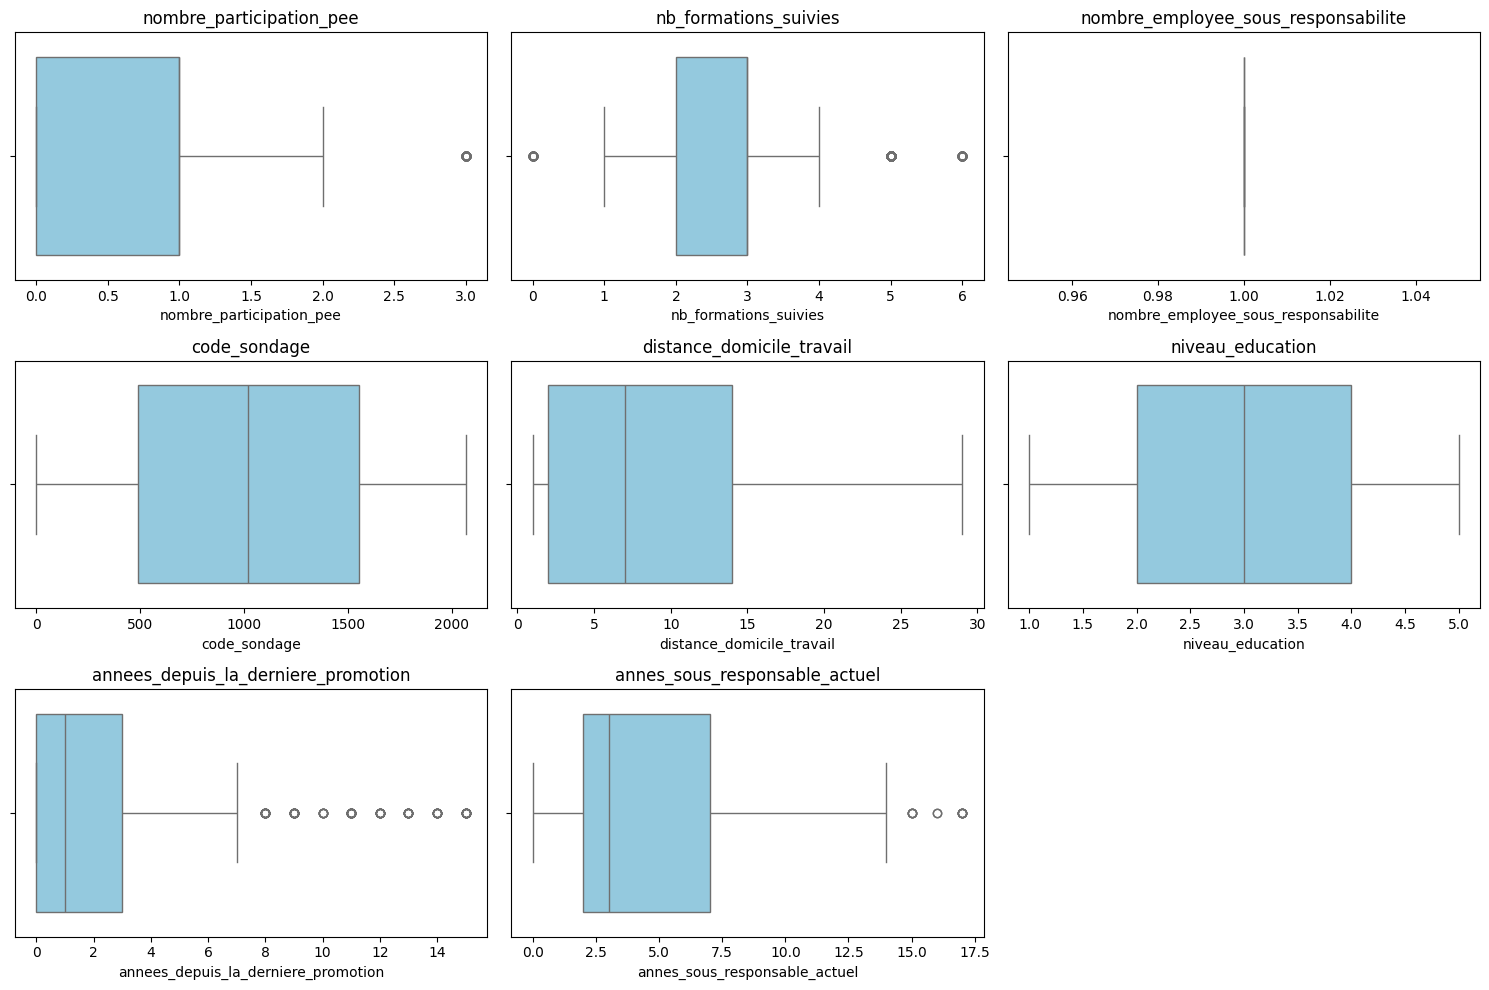

,count,mean,std,min,25%,50%,75%,max,top_val,top_pct
nombre_participation_pee,1470.0,0.79,0.85,0.0,0.00,1.0,1.00,3.0,0,42.93
nb_formations_suivies,1470.0,2.80,1.29,0.0,2.00,3.0,3.00,6.0,2,37.21
nombre_employee_sous_responsabilite,1470.0,1.00,0.00,1.0,1.00,1.0,1.00,1.0,1,100.0
code_sondage,1470.0,1024.87,602.02,1.0,491.25,1020.5,1555.75,2068.0,1,0.07
distance_domicile_travail,1470.0,9.19,8.11,1.0,2.00,7.0,14.00,29.0,2,14.35
niveau_education,1470.0,2.91,1.02,1.0,2.00,3.0,4.00,5.0,3,38.91
annees_depuis_la_derniere_promotion,1470.0,2.19,3.22,0.0,0.00,1.0,3.00,15.0,0,39.52
annes_sous_responsable_actuel,1470.0,4.12,3.57,0.0,2.00,3.0,7.00,17.0,2,23.4


In [12]:
print(df_sondage.info(), '\n')
display(df_sondage.head(3))

# Vérifie s'il y a des doublons dans les identifiants employés et affiche le total
print( df_sondage['code_sondage'].duplicated().sum(), "\n" )

# Génère et affiche le diagnostic univariée pour les colonnes catégorielles
display( diagnostiquer_qualitatives(df_sondage) )

print()

tracer_boxplots(df_sondage)
display( Diagnostique_quanti(df_sondage) )   # pour les colonnes numériques



#### Variables à écarter

* **Constat :** Les variables `ayant_enfants` et `nombre_employee_sous_responsabilite` ont un écart-type de **0**. La variable `code_sondage` est un simple identifiant.
* **Action :** Ces colonnes seront **supprimées**.

####  Déséquilibre de la cible (`Target`)

* **Constat :** Seuls **16%** des employés ont quitté l'entreprise (237 "Oui" contre 1233 "Non").
* **Impact Modèle :** Le jeu de données est **déséquilibré**.

> **Note technique :** Nous ne pourrons pas nous fier uniquement à l'Accuracy (précision globale). Nous devrons surveiller le **Recall** (capacité à détecter ceux qui partent vraiment) pour que le modèle ne se contente pas de prédire "Non" à tout le monde.

#### Leviers de Tension : Distance et Promotion

* **Distance Domicile-Travail  :** Une dispersion importante suggérant que les longs trajets pourraient être un facteur d'usure.
* **Stagnation (Promotion) :** Avec un maximum à **15 ans** sans promotion alors que la moyenne est à 2 ans, nous tenons ici un indicateur de frustration potentielle très fort.

---



### Parcours de Carrière et Management

#### Le "Plafond des Promotions"

* **Constat :** Si 75% des employés obtiennent une promotion dans les 3 ans, certains stagnent jusqu'à **15 ans** au même niveau.
* **Hypothèse :** Le dépassement du seuil des **4 ans sans promotion** est probablement un signal de désengagement majeur que le modèle devra confirmer.

#### L'Impact du Management (`annes_sous_responsable_actuel`)

* **Constat :** Une dispersion très élevée ().
* **Insight :** La relation avec le manager est un pilier de la rétention. Un score de **0 an** (changement récent de manager) ou un score très élevé (lassitude ou dépendance).




# **Jointure Dataframe Centrale**
- Fusion crée Un DataFrame central à partir des 3 fichiers

In [13]:
# Vérification de l'alignement strict des fichiers (ID et Ordre des lignes)
# Si True : on peut fusionner avec concat. Si False : merge obligatoire.
condition = (df_sirh['id_employee'] == df_eval['eval_number']) & (df_eval['eval_number'] == df_sondage['code_sondage'])

print(condition.all())

True


In [14]:
variable_supprimer = ['note_evaluation_actuelle', 'nombre_heures_travailless',
                      'ayant_enfants', 'nombre_employee_sous_responsabilite',
                      'id_employee', 'eval_number', 'code_sondage']

# On fait qd meme le choix avec merge
df_interm = pd.merge(df_sirh, df_eval, left_on='id_employee', right_on='eval_number', how='inner')
df_central = pd.merge(df_interm, df_sondage, left_on='id_employee', right_on='code_sondage', how='inner')

df_central = df_central.drop(columns=variable_supprimer)


In [15]:
# Vérifie si n'importe laquelle des variables est encore là
reste_t_il_des_variables = any(var in df_central.columns for var in variable_supprimer)

if not reste_t_il_des_variables:
    print("Succès : Toutes les variables ont été supprimées.")
else:
    print("Attention : Certaines variables sont encore présentes.")

print()

# Version améliorée pour plus de clarté
for variable in variable_supprimer:
    print(f"La variable '{variable}' est-elle présente ? {variable in df_central.columns}")

Succès : Toutes les variables ont été supprimées.

La variable 'note_evaluation_actuelle' est-elle présente ? False
La variable 'nombre_heures_travailless' est-elle présente ? False
La variable 'ayant_enfants' est-elle présente ? False
La variable 'nombre_employee_sous_responsabilite' est-elle présente ? False
La variable 'id_employee' est-elle présente ? False
La variable 'eval_number' est-elle présente ? False
La variable 'code_sondage' est-elle présente ? False


In [16]:
df_central.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 27 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   age                                        1470 non-null   int64  
 1   genre                                      1470 non-null   str    
 2   revenu_mensuel                             1470 non-null   int64  
 3   statut_marital                             1470 non-null   str    
 4   departement                                1470 non-null   str    
 5   poste                                      1470 non-null   str    
 6   nombre_experiences_precedentes             1470 non-null   int64  
 7   annee_experience_totale                    1470 non-null   int64  
 8   annees_dans_l_entreprise                   1470 non-null   int64  
 9   annees_dans_le_poste_actuel                1470 non-null   int64  
 10  satisfaction_employee_environnement

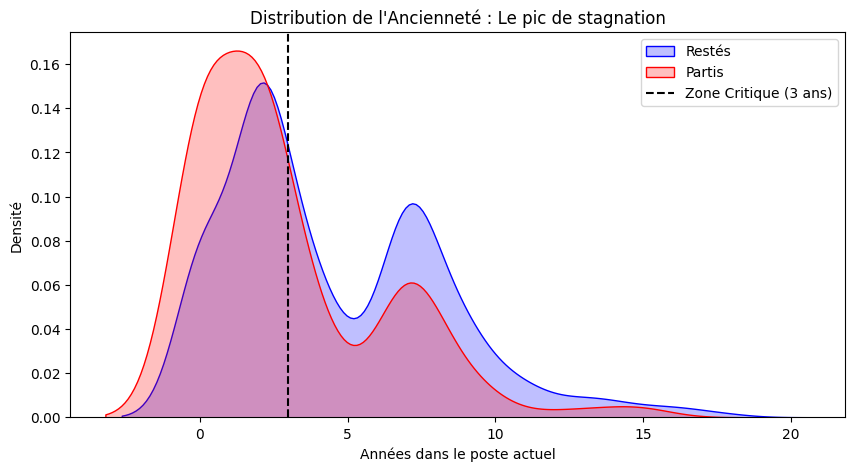

In [17]:
plt.figure(figsize=(10, 5))

sns.kdeplot(data=df_central[df_central['a_quitte_l_entreprise'] == 'Non'], x= 'annees_dans_le_poste_actuel', label='Restés', fill=True, color="blue")
sns.kdeplot(data=df_central[df_central['a_quitte_l_entreprise'] == 'Oui'], x= 'annees_dans_le_poste_actuel', label='Partis', fill=True, color="red")

plt.title("Distribution de l'Ancienneté : Le pic de stagnation")
plt.xlabel("Années dans le poste actuel")
plt.ylabel("Densité")
plt.axvline(3, color='black', linestyle='--', label='Zone Critique (3 ans)')
plt.legend()
plt.show()

C:\Users\D005956\AppData\Local\Temp\4\ipykernel_156112\28388489.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_central, x='heure_supplementaires', y=(df_central['a_quitte_l_entreprise'] == 'Oui'), palette='viridis')


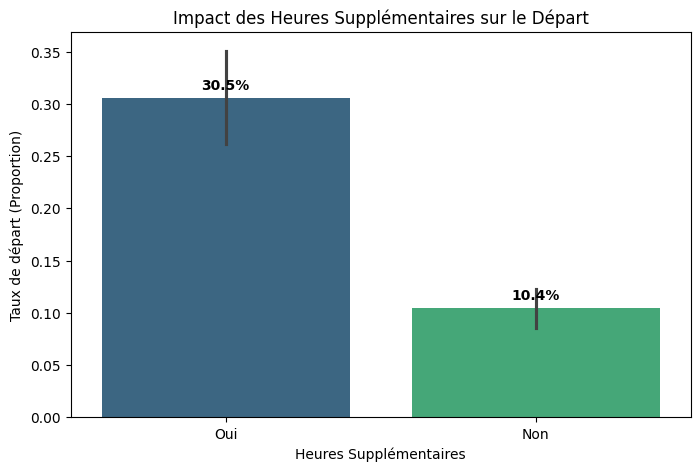

In [18]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(data=df_central, x='heure_supplementaires', y=(df_central['a_quitte_l_entreprise'] == 'Oui'), palette='viridis')

plt.title("Impact des Heures Supplémentaires sur le Départ")
plt.ylabel("Taux de départ (Proportion)")
plt.xlabel("Heures Supplémentaires")

# Pour afficher les % au dessus des barres
for p in ax.patches:
    ax.annotate(f'{p.get_height()*100:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.show()

# **Étape : Nettoyage des Variables Explicatives**

L'objectif est d'isoler les variables qui apportent une information **unique** et d'éliminer les redondances pour garantir la stabilité et l'interprétabilité du futur modèle.

### **1. Variables Quantitatives**

* **Corrélations (Analyses Bivariées)** :
* **Pearson (Paramétrique)** : Mesure la dépendance **linéaire**. Elle est efficace pour les distributions normales mais sensible aux valeurs extrêmes.
* **Spearman (Non-Paramétrique)** : Mesure la relation **monotone** (basée sur les rangs). Elle est plus robuste car elle capture des relations non-linéaires et n'est pas influencée par les outliers.
* **Action** : Si , suppression d'une des deux variables redondantes.


* **VIF - Variance Inflation Factor (Analyse Multivariée)** :
* **Principe** : Contrairement aux tests bivariés, le VIF détecte la **multicolinéarité complexe**. Il vérifie si une variable peut être expliquée par une combinaison linéaire de toutes les autres variables explicatives.
* **Action** : Suppression des variables avec un **VIF > 10** pour éviter l'instabilité des coefficients du modèle.



### **2. Variables Qualitatives**

* **V de Cramér corrigé (Analyse Bivariée)** :
* **Principe (Non-Paramétrique)** : Basé sur le test du **Chi-2**, il mesure la force d'association entre deux variables catégorielles. On utilise la version corrigée pour éviter la surestimation du lien sur les petits échantillons.
* **Action** : Suppression si le **score > 0,70**, signe d'une trop forte dépendance entre deux catégories (ex: redondance entre le département et l'intitulé de poste).





In [19]:
df_std = df_central.copy()
num_cols = df_std.select_dtypes(include='number').columns

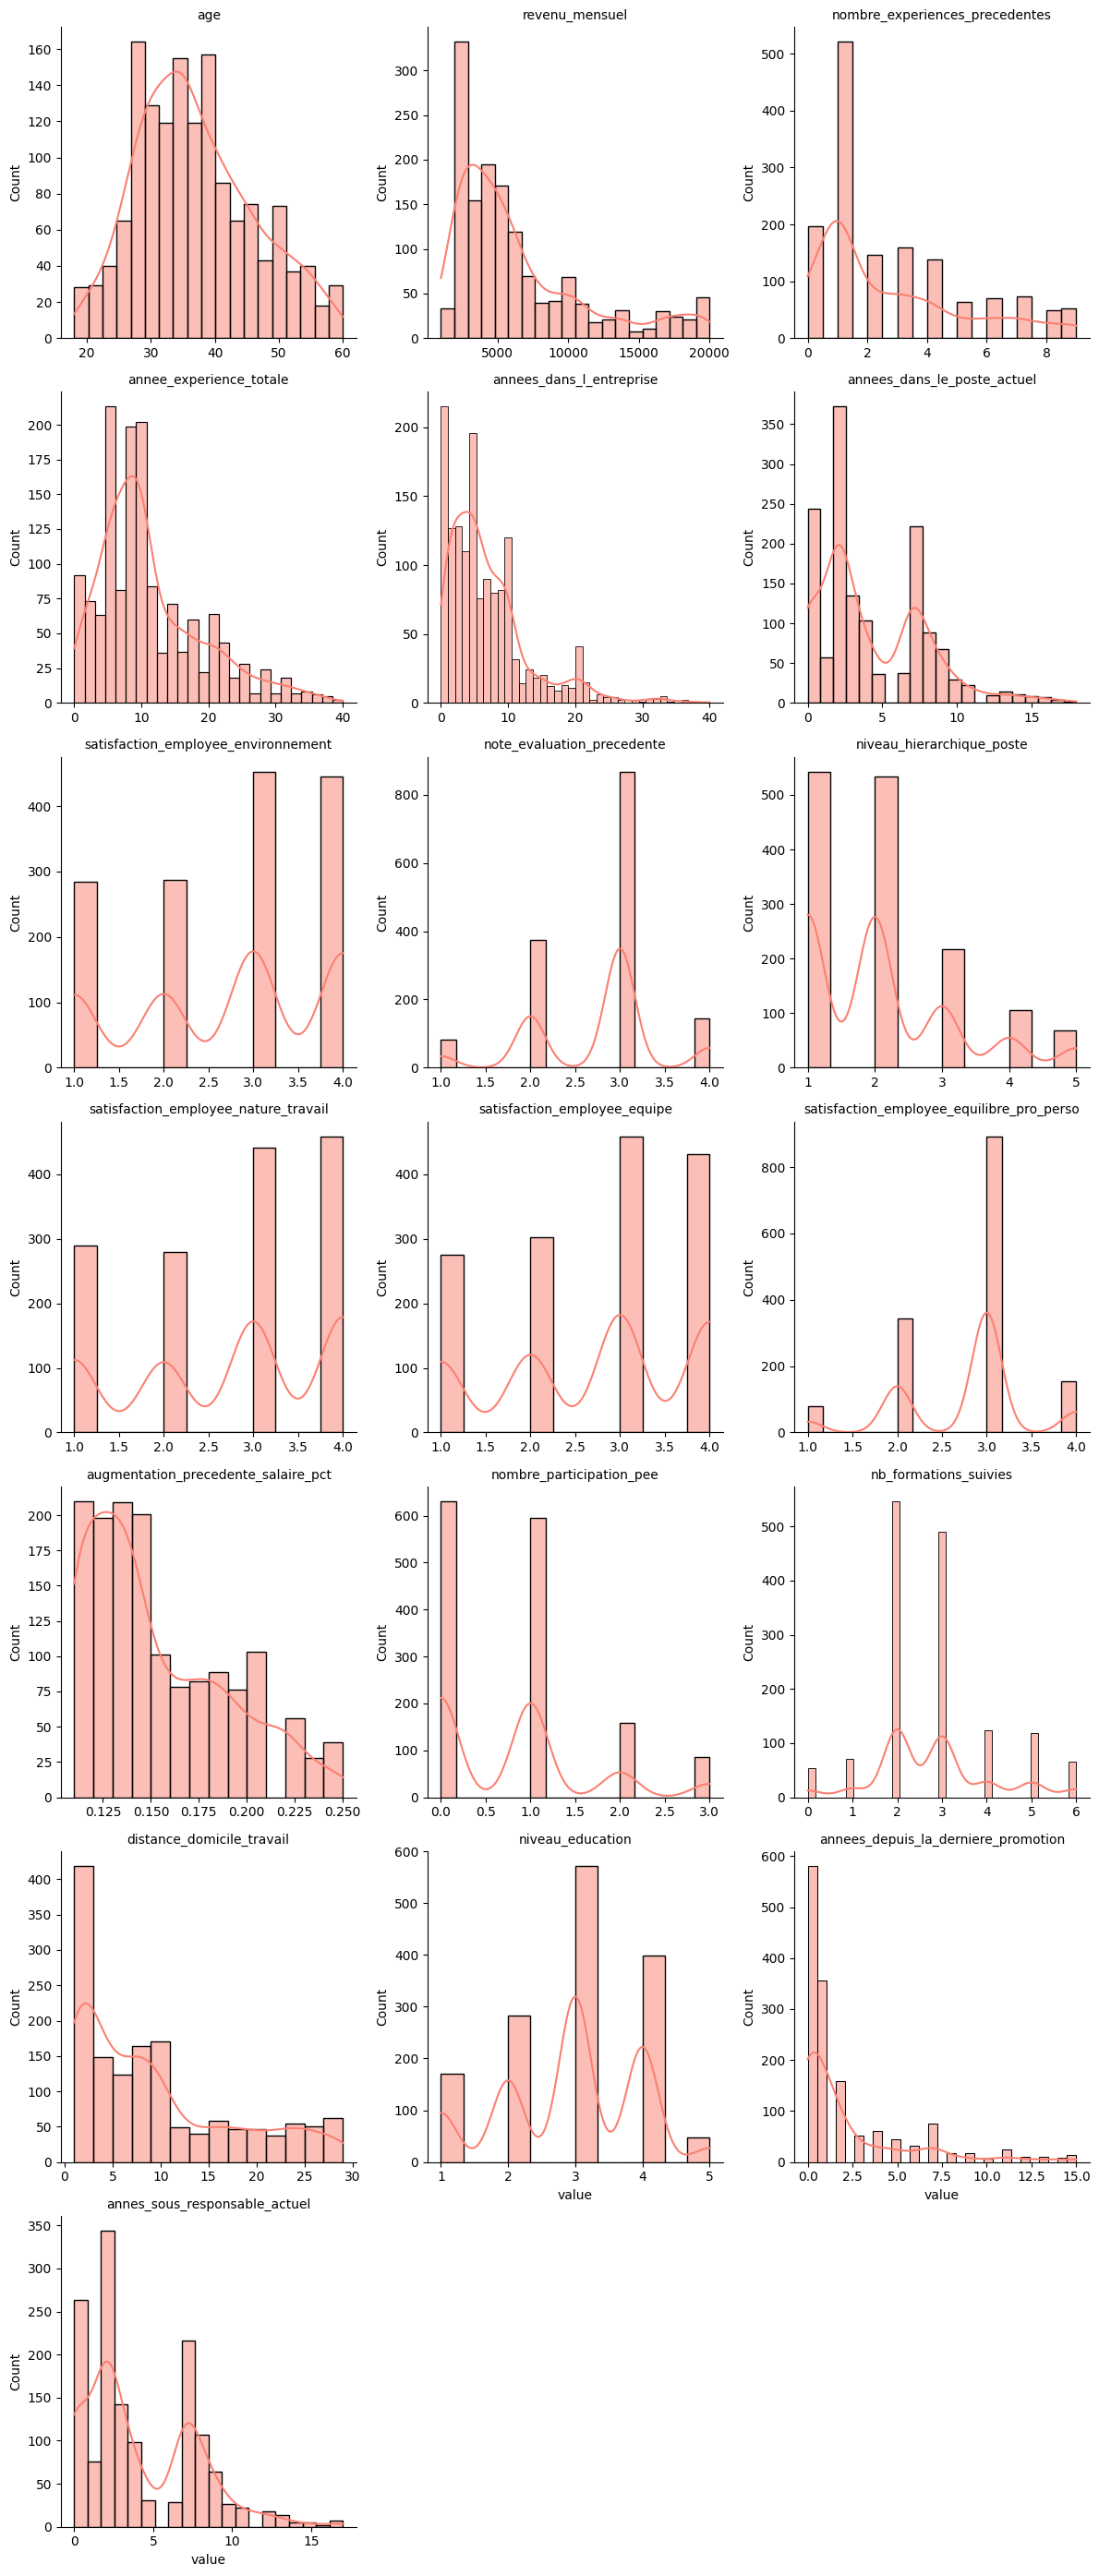

In [20]:
# 1. On transforme les données numériques en format "long"
df_long = df_std[num_cols].melt()

# 2. On prépare la grille de 3 colonnes
g = sns.FacetGrid(df_long, col="variable", col_wrap=3, sharex=False, sharey=False, height=4)

# 3. On dessine les histogrammes (on remplace sns.boxplot par sns.histplot)
g.map(sns.histplot, "value", kde=True, color="salmon")

# 4. On nettoie les titres
g.set_titles("{col_name}")
plt.show()

In [21]:
for col in num_cols:
    # On teste uniquement la colonne en cours : df_std[col]
    stat, p = shapiro(df_std[col])

    print(f"--- Variable : {col} ---")
    if p > 0.05:
        print(f"Stat : {stat:.3f}, P-value : {p:.3f}")
        print("Verdict : Distribution Normale (p > 0.05)")
    else:
        print(f"Stat : {stat:.3f}, P-value : {p:.3f}")
        print("Verdict : Distribution NON Normale (p <= 0.05)")
    print("-" * 30)

--- Variable : age ---
Stat : 0.977, P-value : 0.000
Verdict : Distribution NON Normale (p <= 0.05)
------------------------------
--- Variable : revenu_mensuel ---
Stat : 0.828, P-value : 0.000
Verdict : Distribution NON Normale (p <= 0.05)
------------------------------
--- Variable : nombre_experiences_precedentes ---
Stat : 0.849, P-value : 0.000
Verdict : Distribution NON Normale (p <= 0.05)
------------------------------
--- Variable : annee_experience_totale ---
Stat : 0.907, P-value : 0.000
Verdict : Distribution NON Normale (p <= 0.05)
------------------------------
--- Variable : annees_dans_l_entreprise ---
Stat : 0.839, P-value : 0.000
Verdict : Distribution NON Normale (p <= 0.05)
------------------------------
--- Variable : annees_dans_le_poste_actuel ---
Stat : 0.896, P-value : 0.000
Verdict : Distribution NON Normale (p <= 0.05)
------------------------------
--- Variable : satisfaction_employee_environnement ---
Stat : 0.849, P-value : 0.000
Verdict : Distribution NON

### Aucune Variable suit une distribution Normal

In [22]:
####################################
## Pearson
####################################

# Standardisation
scaler = StandardScaler()
df_std[num_cols] = scaler.fit_transform(df_std[num_cols])

df_corr_pearson = correlations_fortes(df_std, seuil=0.7, methode="pearson")

print("Corrélations Fortes (Pearson) :")
print(df_corr_pearson.to_markdown(index=False, floatfmt=".2f"), "\n")


####################################
## Spearman (pas besoin de scaler)
####################################
df_corr_spearman = correlations_fortes(df_central[num_cols], seuil=0.7, methode="spearman")

print("Corrélations Fortes (Spearman) :")
print(df_corr_spearman.to_markdown(index=False, floatfmt=".2f"), "\n")


############
## VIF
##############
X = df_std[num_cols]

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False))


6 corrélations fortes trouvées (|r| ≥ 0.7)
Corrélations Fortes (Pearson) :
| Var1                        | Var2                          |   Corrélation |   Force_Absolue |
|:----------------------------|:------------------------------|--------------:|----------------:|
| niveau_hierarchique_poste   | revenu_mensuel                |          0.95 |            0.95 |
| annee_experience_totale     | niveau_hierarchique_poste     |          0.78 |            0.78 |
| annee_experience_totale     | revenu_mensuel                |          0.77 |            0.77 |
| annees_dans_l_entreprise    | annes_sous_responsable_actuel |          0.77 |            0.77 |
| annees_dans_l_entreprise    | annees_dans_le_poste_actuel   |          0.76 |            0.76 |
| annees_dans_le_poste_actuel | annes_sous_responsable_actuel |          0.71 |            0.71 | 

6 corrélations fortes trouvées (|r| ≥ 0.7)
Corrélations Fortes (Spearman) :
| Var1                        | Var2                          |

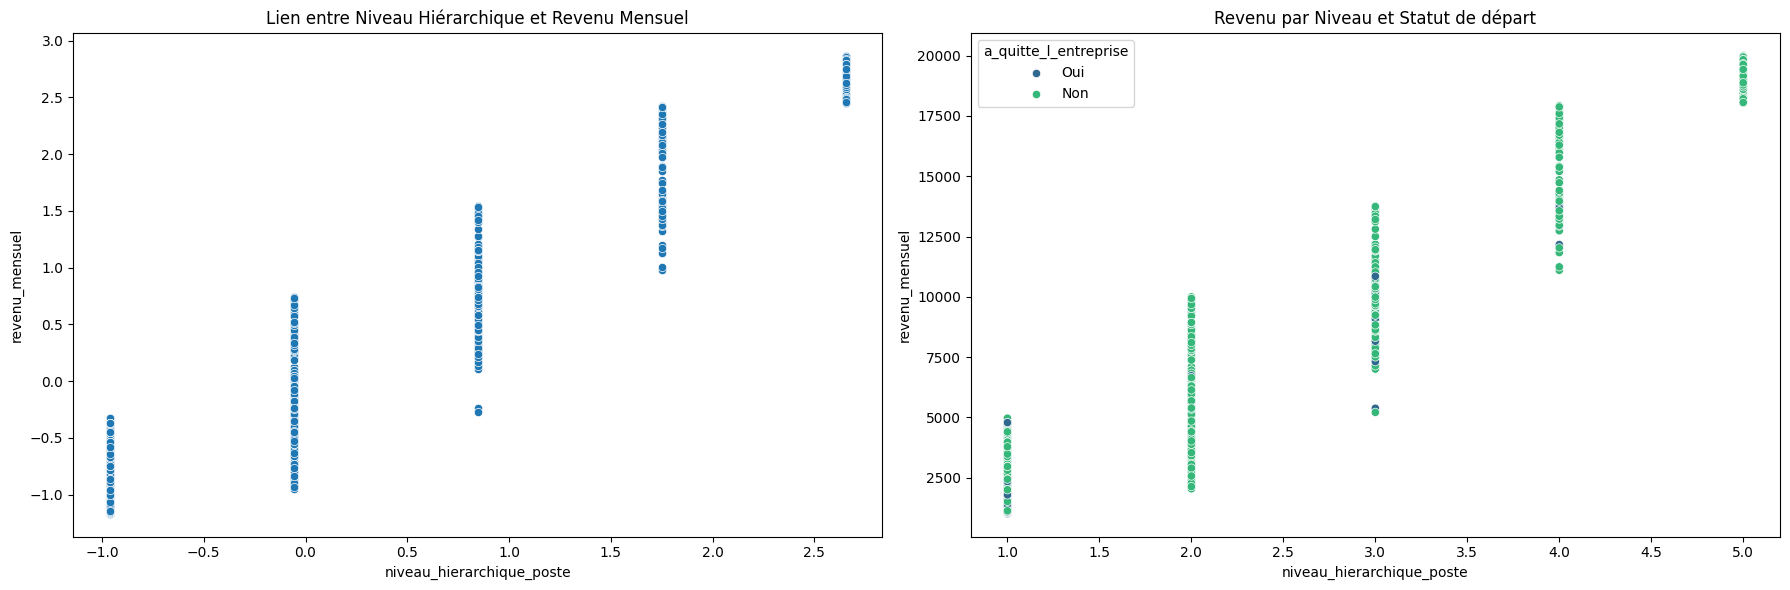

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.scatterplot(data=df_std[num_cols], 
                x='niveau_hierarchique_poste', 
                y='revenu_mensuel', 
                ax=axes[0])
axes[0].set_title("Lien entre Niveau Hiérarchique et Revenu Mensuel")


sns.scatterplot(data=df_central, 
                x='niveau_hierarchique_poste', 
                y='revenu_mensuel', 
                hue='a_quitte_l_entreprise', 
                palette='viridis', 
                ax=axes[1])
axes[1].set_title("Revenu par Niveau et Statut de départ")


plt.tight_layout()
plt.show()



##### **Seuils d'interprétation du VIF**

| Valeur du VIF | Interprétation | Action recommandée |
| --- | --- | --- |
| **VIF = 1** | Aucune corrélation. | **On garde.** La variable est parfaitement indépendante. |
| **1 < VIF < 5** | Corrélation modérée. | **On garde.** C'est souvent le cas pour des variables liées (ex: âge et ancienneté) mais qui restent acceptables. |
| **5 < VIF < 10** | Corrélation forte. | **Zone d'alerte.** À surveiller de près selon l'importance métier de la variable. |
| **VIF > 10** | **Multicolinéarité sévère.** | **On supprime.** La variable est une "copie" d'une combinaison d'autres ; elle rend les coefficients instables. |


#### **1. Priorité à la Granularité : Revenu vs Hiérarchie**

* **Décision :** Suppression de `niveau_hierarchique_poste` (**VIF > 11**) au profit de `revenu_mensuel`.
* **Justification :** Bien que les deux variables soient fortement corrélées, le salaire est une donnée **continue**.
> Elle offre une granularité bien supérieure aux paliers discrets (1, 2, 3...) du niveau hiérarchique, permettant au modèle de capturer des nuances plus fines de positionnement social et de satisfaction financière.

#### **2. Conservation de la Dynamique de Carrière (Variables de Temps)**

* **Décision :** Maintien de toutes les variables de durée (`anciennete`, `annees_au_poste`, etc.), le **VIF restant inférieur à 5**.
* **Justification :** Ces variables ne sont pas redondantes mais **complémentaires**. Leur croisement est essentiel pour identifier des profils comportementaux opposés :
* **L'employé mobile :** Forte ancienneté mais changement de poste récent (signe de dynamisme/évolution).
* **L'employé stagnant :** Forte ancienneté bloquée au même poste (signe de "plafond de verre" ou de lassitude).
* *Supprimer l'une de ces variables ferait perdre au modèle cette capacité de discernement stratégique.*





In [24]:
######################################
##### Suppresion de la variable ######
######################################

df_central = df_central.drop(columns=['niveau_hierarchique_poste'])

print('niveau_hierarchique_poste' in df_central.columns)

False


### **Pour variables explicatives qualitatives**

In [25]:
df_quali= df_central.select_dtypes(include=['object','string'])

# --- UTILISATION ---
df_associations = analyser_associations_quali(df_quali)

# Affichage des fortes associations (> 0.5)
print(df_associations[df_associations['V_Cramer'] > 0.4].to_markdown(index=False))

| Variable 1   | Variable 2    |      p-value |    Chi2 |   V_Cramer |
|:-------------|:--------------|-------------:|--------:|-----------:|
| departement  | poste         | 0            | 2594.43 |   0.767706 |
| departement  | domaine_etude | 7.77159e-214 | 1024.98 |   0.482373 |


In [26]:
variable = ["departement", "poste", "domaine_etude"]

for var in variable:
    print(df_quali[var].value_counts())
    print()

departement
Consulting             961
Commercial             446
Ressources Humaines     63
Name: count, dtype: int64

poste
Cadre Commercial           326
Assistant de Direction     292
Consultant                 259
Tech Lead                  145
Manager                    131
Senior Manager             102
Représentant Commercial     83
Directeur Technique         80
Ressources Humaines         52
Name: count, dtype: int64

domaine_etude
Infra & Cloud              606
Transformation Digitale    464
Marketing                  159
Entrepreunariat            132
Autre                       82
Ressources Humaines         27
Name: count, dtype: int64



In [27]:
# Le poste est beaucoup plus granulaire. On va supprimer la variable Département

df_central = df_central.drop(columns=['departement'])

print('departement' in df_central.columns)

False


In [28]:
# filtrage ciblé pour isoler les relations avec la variable cible

condition = (df_associations["Variable 1"] == "a_quitte_l_entreprise") | (df_associations["Variable 2"] == "a_quitte_l_entreprise")
display(df_associations.loc[condition, :])

,Variable 1,Variable 2,p-value,Chi2,V_Cramer
3,heure_supplementaires,a_quitte_l_entreprise,8.158424e-21,87.564294,0.172608
4,poste,a_quitte_l_entreprise,2.752482e-15,86.190254,0.171449
5,statut_marital,a_quitte_l_entreprise,9.455511e-11,46.163677,0.125348
6,a_quitte_l_entreprise,frequence_deplacement,5.608614e-06,24.182414,0.090722
9,a_quitte_l_entreprise,domaine_etude,6.773980e-03,16.024674,0.073883
10,departement,a_quitte_l_entreprise,4.525607e-03,10.796007,0.060615
24,genre,a_quitte_l_entreprise,2.905724e-01,1.116967,0.019489


# **Etape 2 BIS : Recherche de Pertinence avec la Variable Cible (Mutual Information)**

### **Pourquoi faire cette étape ?**

Alors que la corrélation ou le VIF cherchent la redondance entre variables, **l'Information Mutuelle (MI)** cherche la **pertinence (Pouvoir Prédictif)** vis-à-vis de la cible.

* **Universalité** : Contrairement à Pearson (linéaire) ou Kruskal-Wallis (différence de moyennes), le MI capture **n'importe quel type de relation** (courbes, paliers, catégories complexes).
* **Non-paramétrique** : Elle ne fait aucune supposition sur la distribution des données (pas besoin de loi normale).

### **Actions et Diagnostic**

L'analyse du score MI permet de prendre trois décisions critiques :

1. **Détection du Data Leakage** :
     * **Indicateur** : Un score MI exceptionnellement élevé ().
     * **Action** : `Suppression` ou `Feature Engineering`

2. **Top Features (Analyse univariée)** :
    * **Indicateur** : Scores significativement au-dessus de zéro.
    * **Action** : `Priorisation` de ces variables pour l'entraînement du modèle.

3. **Élimination du Bruit** :
   * **Indicateur** : Score nul ou proche de zéro.
   * **Action** : `Suppression` pour éviter d'ajouter du "bruit" et de dégrader la précision (Overfitting).

> **PS** : Ce sont des hypothèses à tester et à affiner lors du lancement et de l'évaluation du modèle choisi.

In [29]:
# 1. Calcul (on factorise pour gérer le texte rapidement)
X_mi = df_central.drop(columns=['a_quitte_l_entreprise']).apply(lambda x: pd.factorize(x)[0])
mi_scores = mutual_info_classif(X_mi, df_central['a_quitte_l_entreprise'], random_state=42)

# 2. Affichage
mi_res = pd.DataFrame({'Feature': X_mi.columns, 'Score': mi_scores}).sort_values(by='Score', ascending=False)
mi_res.style.background_gradient(cmap='Reds')

,Feature,Score
4,poste,0.029881
8,annees_dans_le_poste_actuel,0.029300
6,annee_experience_totale,0.026346
16,nombre_participation_pee,0.021417
21,frequence_deplacement,0.020078
9,satisfaction_employee_environnement,0.018846
0,age,0.018337
20,domaine_etude,0.017720
14,heure_supplementaires,0.016188
3,statut_marital,0.013994




#### **1. Intégrité du Dataset : Absence de Data Leakage**

* **Constat :** Aucun score ne dépasse **0.8**.
* **Conclusion :** Le dataset est sain. Aucune variable explicative ne contient de "fuite" d'information (donnée connue seulement après le départ), ce qui garantit la fiabilité des futures prédictions.

#### **2. La Fatigue du Poste**

* **Top Features :** `Poste`, `Ancienneté dans le poste`, `Expérience totale`.
* **Insight :** Le turnover est structurel. Le risque de départ est corrélé à la **stagnation professionnelle**. Ce n'est pas une impulsion, mais une lassitude liée au cycle de vie dans la mission. Un employé dont les tâches n'évoluent plus est le profil prioritaire à surveiller.

#### **3. Le Paradoxe du Salaire : L'Information est "Noyée"**

* **Constat :** Le `Revenu_Mensuel` brut affiche un score MI proche de **0**.
* **Analyse :** Ce score nul ne signifie pas que le salaire n'importe pas, mais que sa valeur absolue est un **bruit**. 3000€ peut être une excellente rétention pour un technicien, mais une insulte pour un directeur. L'information de satisfaction financière est perdue dans la masse globale.
* **Stratégie (Feature Engineering) :** Nous devons créer une variable de **Salaire Relatif** (Individu vs Moyenne du poste) pour transformer ce bruit en signal prédictif.

#### **4. Signaux Faibles et Biais de Déclaration**

* **Constat :** La `Satisfaction Nature du Travail` est proche de **0**.
* **Hypothèse :** Soit les facteurs logistiques (distance, management) écrasent totalement l'intérêt du métier, soit les sondages de satisfaction interne souffrent d'un biais de complaisance (réponses peu sincères).





# **Étape : Feature Engineering Stratégique**

Le Feature Engineering consiste à transformer les données brutes pour créer de nouveaux indicateurs plus "parlants" pour le modèle. Nous avons sélectionné 4 leviers prioritaires :

### **Tableau de Bord des Transformations**

| Levier | Type de Feature | Variable Créée | Logique Statistique | Objectif Métier |
| --- | --- | --- | --- | --- |
| **Équité Salariale** | **Agrégation (Ratio)** | `ratio_salaire_poste` | Corrige le **MI nul** du salaire brut en le contextualisant. | Isoler la frustration : être sous-payé *par rapport à ses pairs* est le vrai driver de départ. |
| **Charge Mentale** | **Interaction** | `indice_penibilite` | Croisement entre `poste` et `frequence_deplacement`. | Capturer l'usure : un voyageur fréquent dont le métier n'est pas "nomade" subit une pénibilité accrue. |
| **Temps d'Attente** | **Transformation (Clipping)** | `attente_promo_réelle` | Correction des incohérences temporelles (valeurs négatives). | Mesurer la **frustration pure** : isoler la stagnation réelle en supprimant le bruit des mutations. |
| **Lien Managérial** | **Ratio Temporel** | `ratio_fidelite_manager` | Proportion de l'ancienneté passée sous le même manager. | Détecter la dépendance : l'employé suit-il son manager ou subit-il le même management trop longtemps ? |




In [30]:
df_eng = df_central.copy()


### **1. Agrégation : Le Ratio de Salaire**
# On calcule le salaire moyen par poste et on crée le ratio
salaire_moyen_par_poste = df_eng.groupby('poste')['revenu_mensuel'].transform('mean')   # On stocke la moyenne de référence par poste dans une variable (Série)
df_eng['ratio_salaire_poste'] = df_eng['revenu_mensuel'] / salaire_moyen_par_poste


# 2. Ratio d'évolution interne (Stagnation)
# Un ratio de 1 signifie que l'employé n'a jamais bougé de poste depuis son arrivée.
df_eng['ratio_stagnation'] = df_eng['annees_dans_le_poste_actuel'] / (df_eng['annees_dans_l_entreprise'] + 0.1)

# 3. Interaction Poste x Déplacements (Pénibilité)
# On combine le métier et la fréquence des voyages (ex: 'Sales_Travel_Frequently')
df_eng['poste_penibilite_voyage'] = df_eng['poste'].astype(str) + "_" + df_eng['frequence_deplacement'].astype(str)


# 4. Indice de frustration (Attente de promotion)
# On regarde le temps passé dans le poste SANS avoir eu de promotion.
df_eng['attente_promotion_pure'] = df_eng['annees_dans_le_poste_actuel'] - df_eng['annees_depuis_la_derniere_promotion']


# 5. Binôme Manager-Employé (Lien avec le responsable)
# Si ce ratio est élevé, l'employé est "bloqué" avec le même manager depuis longtemps.
df_eng['ratio_fidelite_manager'] = df_eng['annes_sous_responsable_actuel'] / (df_eng['annees_dans_le_poste_actuel'] + 0.1)

In [31]:
#### vérification  :

nouvelles_cols = ['ratio_salaire_poste', 'ratio_stagnation', 'poste_penibilite_voyage', 'attente_promotion_pure', 'ratio_fidelite_manager']
X_new = df_eng[nouvelles_cols].apply(lambda x: pd.factorize(x)[0])
y = df_eng['a_quitte_l_entreprise']

# Calcul du MI
mi_new = mutual_info_classif(X_new, y, random_state=42)

# Affichage du comparatif
display(pd.DataFrame({'Nouvelle Feature': nouvelles_cols, 'Score_MI': mi_new}).sort_values(by='Score_MI', ascending=False))


print()

display(df_eng[ nouvelles_cols ].describe().T)

,Nouvelle Feature,Score_MI
2,poste_penibilite_voyage,0.045122
4,ratio_fidelite_manager,0.024664
1,ratio_stagnation,0.024458
3,attente_promotion_pure,0.023823
0,ratio_salaire_poste,0.008241


,count,mean,std,min,25%,50%,75%,max
ratio_salaire_poste,1470.0,1.000000,0.344599,0.311422,0.743263,0.918829,1.178757,3.001260
ratio_stagnation,1470.0,0.565733,0.323119,0.000000,0.350835,0.645161,0.819672,0.985915
attente_promotion_pure,1470.0,2.041497,3.273183,-10.000000,0.000000,1.000000,4.000000,16.000000
ratio_fidelite_manager,1470.0,2.423330,9.635502,0.000000,0.487805,0.952381,1.098901,120.000000


### **1. Constat Mutual Information (MI) :**

* **`poste_penibilite_voyage` (0.045)** : C'est ta variable la plus forte.
On voit que Tu as prouvé que le départ n'est pas dû au métier seul, ni au voyage seul, mais à la **combinaison des deux**. C'est le signal le plus clair pour ton futur modèle.


* On constate les ratios de carrière (~0.024)`ratio_fidelite_manager`, `ratio_stagnation` et `attente_promotion_pure` tournent tous autour du même score. La dynamique de carrière (temps passé sans promotion vs temps dans le poste) est un facteur de départ **3 fois plus important** que le salaire brut.


*  `ratio_salaire_poste` (0.008) Le score n'est plus à 0, mais il reste faible.
Dans cette entreprise, l'argent est un facteur secondaire. Les employés partent pour des raisons d'usure et de management plutôt que pour une question de fiche de paie.



---

### **2. Analyse des statistiques descriptives : Outliers !**


* **Le problème `attente_promotion_pure` (min = -10)** :
    * Valeurs négatives. Cela signifie que le modèle va être confus.
    * *Action :* Il faut appliquer le `.clip(lower=0)` pour que toutes ces valeurs incohérentes deviennent 0.


* **Le problème `ratio_fidelite_manager` (max = 120)** :
    * C'est impossible (cela signifierait que quelqu'un a passé 120 fois plus de temps avec son manager que dans son poste). C'est une erreur de donnée (outlier).
    * *Action :* Il faut plafonner cette valeur à **1.0** (ou un peu plus si on compte les mutations), car normalement on ne peut pas passer plus de temps avec un manager qu'on n'en a passé dans l'entreprise !


* **La validation `ratio_salaire_poste` (mean = 1.0)** :
    * C'est parfait ! Une moyenne de 1.0 prouve que ton calcul d'agrégation est mathématiquement correct. Tu as bien centré tes données autour de la moyenne du poste.


In [32]:
########################################""
#### Vérification des Incoherence  #####
##########################################

# Affiche les employés dont la promotion précède le poste actuel
incoherents_promo = df_eng[df_eng['attente_promotion_pure'] < 0]
print(f"Nombre de lignes incohérentes (Promotion) : {len(incoherents_promo)}")
display( incoherents_promo[['poste', 'annees_dans_le_poste_actuel', 'annees_depuis_la_derniere_promotion', 'attente_promotion_pure']].head() )

print()

# Affiche les employés dont le temps avec le manager dépasse le temps dans le poste
# (On cherche les ratios > 1.1 pour laisser une petite marge d'erreur de saisie)
incoherents_manager = df_eng[df_eng['ratio_fidelite_manager'] > 1.1]

print(f"Nombre de lignes incohérentes (Manager) : {len(incoherents_manager)}")
display( incoherents_manager[['poste', 'annes_sous_responsable_actuel', 'annees_dans_le_poste_actuel', 'ratio_fidelite_manager']].sort_values(by='ratio_fidelite_manager', ascending=False).head() )



Nombre de lignes incohérentes (Promotion) : 159


,poste,annees_dans_le_poste_actuel,annees_depuis_la_derniere_promotion,attente_promotion_pure
12,Assistant de Direction,2,4,-2
26,Assistant de Direction,2,6,-4
32,Consultant,0,1,-1
34,Assistant de Direction,0,2,-2
46,Cadre Commercial,5,8,-3



Nombre de lignes incohérentes (Manager) : 363


,poste,annes_sous_responsable_actuel,annees_dans_le_poste_actuel,ratio_fidelite_manager
1135,Senior Manager,12,0,120.0
1372,Tech Lead,9,0,90.0
1188,Cadre Commercial,9,0,90.0
652,Cadre Commercial,9,0,90.0
32,Consultant,8,0,80.0


In [33]:
##########################################
####  Correction ciblée des anomalies  ###
##########################################

# 1. On corrige l'attente de promotion (les -10 deviennent 0)
df_eng['attente_promotion_pure'] = df_eng['attente_promotion_pure'].clip(lower=0)

# 2. On corrige la fidélité manager (le 120 devient 1.1)
# On choisit 1.1 pour dire "temps plein avec le manager" tout en gardant une petite marge
df_eng['ratio_fidelite_manager'] = df_eng['ratio_fidelite_manager'].clip(upper=1.1)


display(df_eng[ nouvelles_cols ].describe().T)


,count,mean,std,min,25%,50%,75%,max
ratio_salaire_poste,1470.0,1.000000,0.344599,0.311422,0.743263,0.918829,1.178757,3.001260
ratio_stagnation,1470.0,0.565733,0.323119,0.000000,0.350835,0.645161,0.819672,0.985915
attente_promotion_pure,1470.0,2.359864,2.786556,0.000000,0.000000,1.000000,4.000000,16.000000
ratio_fidelite_manager,1470.0,0.739259,0.404214,0.000000,0.487805,0.952381,1.098901,1.100000


## **TARGET**

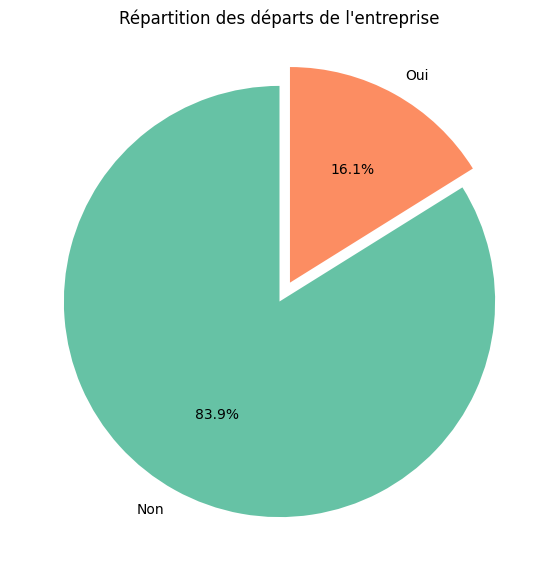

In [34]:
# 1. Compter les valeurs (ex: combien sont partis vs restés)
counts = df_central['a_quitte_l_entreprise'].value_counts()

# 2. Configurer le style Seaborn
sns.set_palette("Set2")
plt.figure(figsize=(7, 7))

# 3. Créer le camembert
plt.pie(counts,
        labels = counts.index,
        autopct = '%1.1f%%',
        startangle = 90,
        explode=(0, 0.1)
        #wedgeprops = {'edgecolor': 'white'}) # Ajoute une petite séparation blanche
)

plt.title("Répartition des départs de l'entreprise")
plt.show()

# **Partie Modélisation**

## **Séparation Train / Test**

In [35]:
def split_data(X, y):
    """
    Divise l'ensemble de données en jeux d'entraînement et de test.

    Args:
        X (pd.DataFrame): Les caractéristiques (features).
        y (pd.Series): La variable cible (target).

    Returns:
        tuple: (X_train, X_test, y_train, y_test)
    """

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.25,    # 25% de l'échantillon pour le test
        random_state=42,   # 'seed' pour garantir la reproductibilité de la division
        stratify=y,        # On assure que les deux morceaux on la meme proprotion
        shuffle=True
    )

    return X_train, X_test, y_train, y_test



def comparer_repartition_target(y_train, y_test, titre="Comparaison Train vs Test", labels=['Classe 0', 'Classe 1']):
    """
    Affiche un barplot comparant les proportions de la cible entre Train et Test.
    """
    # 1. Calcul des proportions (normalize=True pour comparer des tailles différentes)
    train_prop = pd.Series(y_train).value_counts(normalize=True).sort_index()
    test_prop = pd.Series(y_test).value_counts(normalize=True).sort_index()

    # 2. Préparation dynamique du DataFrame pour Seaborn
    # On multiplie les labels par 2 (une fois pour Train, une fois pour Test)
    df_plot = pd.DataFrame({
        'Classe': labels * 2,
        'Proportion': list(train_prop) + list(test_prop),
        'Dataset': ['Train'] * len(labels) + ['Test'] * len(labels)
    })

    # 3. Affichage
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df_plot, x='Classe', y='Proportion', hue='Dataset')

    plt.title(titre)
    plt.ylabel("Proportion (0.0 à 1.0)")
    plt.ylim(0, 1)
    plt.show()


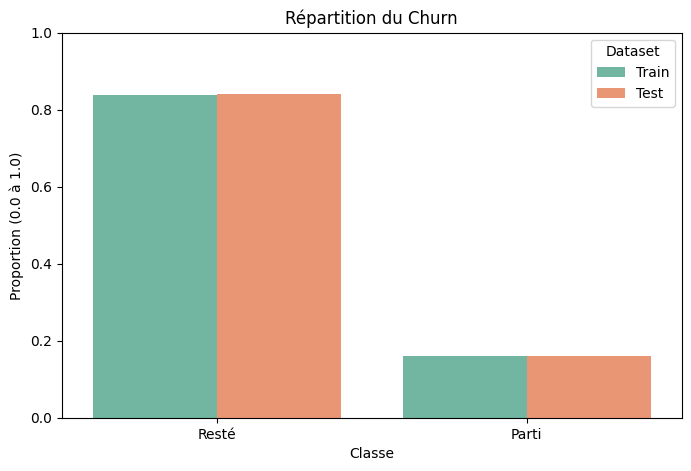

In [36]:
y = df_central['a_quitte_l_entreprise']
X_classique =  df_central.drop(['a_quitte_l_entreprise'], axis=1)


# Appel de la fonction Split
_, _, y_train, y_test = split_data(X_classique, y)

# ===================================
# VERIFICATION DE LA VARIABLE CIBLE
# ===================================

comparer_repartition_target(y_train, y_test,
                            titre="Répartition du Churn",
                            labels=['Resté', 'Parti'])

## **Prétraitement Automatique**

- **Gestion des valeurs manquantes**
- **Standardidation :** avec médiane IQR ce qui permet de mettre toutes les variables sur une échelle comparable sans que les valeurs aberrantes ne faussent la distribution.
- **Gestion des modalités**
   - Pas bcp de modalité -10 et pas d'ordre `(One-Hot Encoding)`
   - Modalité égale à 2 `(Binary Encoding)` eviter colinéarité.

In [37]:
def prétraitement_automatique(X, y):
    # 1. DIVISION (Appel de la fonction)
    X_train, X_test, y_train, y_test = split_data(X, y)

    # 2. IDENTIFICATION DES COLONNES
    va_quali = X_train.select_dtypes(include=['object','string']).columns.tolist()
    va_number = X_train.select_dtypes(include=['number']).columns.tolist()

    # 3. DÉFINITION DU TRANSFORMATEUR
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", RobustScaler())
            ]), va_number),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("cat_enco", OneHotEncoder(drop='if_binary', sparse_output=False, handle_unknown='ignore'))
            ]), va_quali)
        ],
        remainder="passthrough"
    )

    # Configuration pour sortir du Pandas
    preprocessor.set_output(transform="pandas")

    # 4. APPLICATION SUR X (On apprend sur Train, on applique sur Test)
    X_train_trans = preprocessor.fit_transform(X_train)
    X_test_trans = preprocessor.transform(X_test)

    # 5. TRANSFORMATION DE Y (Target)
    # On utilise LabelEncoder pour transformer les classes en 0 et 1
    label_encoder = LabelEncoder()
    y_train_enco = label_encoder.fit_transform(y_train)
    y_test_enco = label_encoder.transform(y_test)

    # RETOUR (On rajoute les objets preprocessor et encoder pour la suite)
    return X_train_trans, X_test_trans, y_train_enco, y_test_enco, preprocessor, label_encoder

# **Techniques de réequilibrage**

### **Rééquilibrage avec `SMOTE` et lutte contre le Data Leakage**

Pour améliorer la détection de la classe minoritaire, nous utilisons la technique **SMOTE** (Synthetic Minority Over-sampling Technique). Cependant, son application doit suivre une règle stricte :

* **Application exclusive au jeu d'entraînement :** Le rééchantillonnage ne doit s'appliquer qu'aux données d'apprentissage. Le jeu de test doit rester **"pur"** et représentatif de la réalité du terrain (donc déséquilibré).
* **Risque de Data Leakage :** Si le SMOTE est appliqué sur l'ensemble du dataset avant le split, des informations du futur jeu de test "fuient" dans l'entraînement via les points synthétiques. Cela créerait des performances artificiellement gonflées et un échec total du modèle en production.



# **Stratégie d'évaluation**

### **1. Validation croisée robuste**

* **`StratifiedKFold` :** Pour contrer le déséquilibre des classes, chaque segment (fold) conserve la proportion initiale de démissions (ex: 16% de départs dans chaque fold). Cela garantit que le modèle est entraîné et testé sur des échantillons toujours représentatifs de la réalité RH..

### **2. Métriques de performance**

Nous privilégions des indicateurs adaptés au déséquilibre des données :

* **`AUPRC` (Area Under the Precision-Recall Curve) :** Bien plus fiable que l'AUC-ROC sur des classes déséquilibrées. Elle mesure la capacité du modèle à isoler les démissions sans être "aveuglé" par la masse d'employés qui restent.
* **`F-Beta Score` :** Permet d'ajuster le curseur entre la précision et la détection.

### **3. Choix du  (Le compromis Métier)**

* **F1-score () :** Équilibre strict entre Précision et Rappel.
* **F2-score () :** `**Notre choix cible.**` On accorde deux fois plus d'importance au **Rappel**.
* **Justification :** Un départ non détecté (Faux Négatif) coûte beaucoup plus cher (coût de recrutement, perte de savoir-faire) qu'une fausse alerte (Faux Positif) qui se solde simplement par un entretien managérial préventif.



In [38]:
############################
###### Configuration  ######
############################

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
f2_scorer = make_scorer(fbeta_score, beta=2)

# Configuration du dictionnaire de scoring
scoring = {
    'AUPRC': 'average_precision',
    'F2': f2_scorer
}


############################################
## MODELE Choisi parametre par défaut ######
############################################

models = {
    # Baseline
    "Dummy": DummyClassifier(strategy="stratified", random_state=42),

    # Modèles Semi-Linéaires
    "Reg_log": LogisticRegression(random_state=42, max_iter=1000),
    "Reg_log_balanced": LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),

    # Modèles Non-Linéaires (Arbres)
    "RF": RandomForestClassifier(random_state=42),
    "RF_balanced": RandomForestClassifier(class_weight='balanced', random_state=42),

    # Modèles Boosting
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),

}




def evaluer_modeles_smote(X, y, models, cv_splitter, scoring_metrics):
    """
    Evalue les modèles sur des données déjà pré-traitées en appliquant
    SMOTE uniquement pendant la validation croisée.
    """
    summary_list = []

    for name, model in models.items():
        # Pipeline : SMOTE -> Modèle
        # SMOTE sera appliqué fold par fold automatiquement
        pipeline_smote = Pipeline([
            ('smote', SMOTE(random_state=42)),
            ('classifier', model)
        ])

        # Validation croisée
        cv_results = cross_validate(
            pipeline_smote,
            X,
            y,
            cv=cv_splitter,
            scoring=scoring_metrics,
            return_train_score=True,
            n_jobs=-1
        )

        # Compilation des résultats
        res = {"Modèle": name}
        for metric in scoring_metrics.keys():
            train_m = cv_results[f"train_{metric}"]
            val_m = cv_results[f"test_{metric}"]

            res[f"Train {metric}"] = f"{train_m.mean():.3f} (±{train_m.std():.3f})"
            res[f"Val {metric}"]   = f"{val_m.mean():.3f} (±{val_m.std():.3f})"

        summary_list.append(res)

    return pd.DataFrame(summary_list)

In [39]:
# ==============================================================================
# PHASE 1 : GÉNÉRATION DES JEUX DE DONNÉES (PRÉTRAITEMENT)
# ==============================================================================

y = df_central['a_quitte_l_entreprise']

# Variante A : Données classiques (brutes)
X_classique = df_central.drop(['a_quitte_l_entreprise'], axis=1)

# Variante B : Données enrichies (Feature Engineering)
X_feature_eng = df_eng.drop(['a_quitte_l_entreprise'], axis=1)


# Application du pipeline de nettoyage (Split + Imputation + Scaling + Encoding)
# 1. Pour les données classiques
X_train_sans_f, X_test_sans_f, y_train_sans_f, y_test_sans_f, prepro_sans, label_enc_sans = prétraitement_automatique(X_classique, y)

# 2. Pour les données avec Feature Engineering
X_train_avec_f, X_test_avec_f, y_train_avec_f, y_test_avec_f, prepro_avec, label_enc_avec = prétraitement_automatique(X_feature_eng, y)

# ==============================================================================
# PHASE 2 : ÉVALUATION COMPARATIVE AVEC SMOTE
# ==============================================================================

# 1. Évaluation sur les données classiques
resultats_sans_f = evaluer_modeles_smote(X_train_sans_f, y_train_sans_f, models, skf, scoring)

# 2. Évaluation sur les données avec Feature Engineering
resultats_avec_f = evaluer_modeles_smote( X_train_avec_f, y_train_avec_f, models, skf, scoring)

# ==============================================================================
# PHASE 3 : AFFICHAGE DES RÉSULTATS
# ==============================================================================

print("\n RÉSULTATS - DONNÉES CLASSIQUES")
display(resultats_sans_f)

print("\n RÉSULTATS - AVEC FEATURE ENGINEERING")
display(resultats_avec_f)


 RÉSULTATS - DONNÉES CLASSIQUES


,Modèle,Train AUPRC,Val AUPRC,Train F2,Val F2
0,Dummy,0.163 (±0.009),0.168 (±0.016),0.354 (±0.033),0.368 (±0.067)
1,Reg_log,0.691 (±0.018),0.614 (±0.078),0.691 (±0.022),0.634 (±0.068)
2,Reg_log_balanced,0.691 (±0.018),0.614 (±0.078),0.691 (±0.022),0.634 (±0.068)
3,RF,1.000 (±0.000),0.577 (±0.062),1.000 (±0.000),0.380 (±0.082)
4,RF_balanced,1.000 (±0.000),0.577 (±0.062),1.000 (±0.000),0.380 (±0.082)
5,XGBoost,1.000 (±0.000),0.584 (±0.070),1.000 (±0.000),0.434 (±0.081)



 RÉSULTATS - AVEC FEATURE ENGINEERING


,Modèle,Train AUPRC,Val AUPRC,Train F2,Val F2
0,Dummy,0.163 (±0.009),0.168 (±0.016),0.354 (±0.033),0.368 (±0.067)
1,Reg_log,0.733 (±0.014),0.628 (±0.057),0.696 (±0.024),0.643 (±0.066)
2,Reg_log_balanced,0.733 (±0.014),0.628 (±0.057),0.696 (±0.024),0.643 (±0.066)
3,RF,1.000 (±0.000),0.582 (±0.065),1.000 (±0.000),0.343 (±0.095)
4,RF_balanced,1.000 (±0.000),0.582 (±0.065),1.000 (±0.000),0.343 (±0.095)
5,XGBoost,1.000 (±0.000),0.579 (±0.053),1.000 (±0.000),0.424 (±0.065)




L'analyse des résultats met en évidence trois points clés :

* **Surapprentissage des modèles complexes :** Random Forest et XGBoost affichent des scores parfaits en entraînement () mais s'effondrent en validation. Sur ce volume de données, ils mémorisent le bruit au lieu d'apprendre les tendances. Ils ne parviennent pas à généraliser sur des données simples.
* **Stabilité de la Régression Logistique :** C'est le modèle le plus robuste. Avec un **F2-score de 0.64** en validation, il surclasse nettement le modèle aléatoire (Dummy) et reste le plus fiable pour une mise en production.
* **Simplicité gagnante :** Ni le `class_weight`, ni le *`Feature Engineering`* n'apportent d'amélioration significative. Le signal principal est déjà capturé par les données brutes ; complexifier le modèle n'ajoute ici que de l'instabilité sans gain de performance.


# **Optimisation des hyperparametres bu Best Model**

In [40]:
import warnings
warnings.filterwarnings('ignore')

# 1. Pipeline robuste
pipe_logreg = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=2000, random_state=42))
])

# 2. Grille de recherche intelligente
# Note : On utilise liblinear pour qu'il puisse gérer L1 et L2 sans planter
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['lbfgs','liblinear'],
    'classifier__class_weight': ['balanced', None]
}

# 3. Configuration du GridSearchCV
grid = GridSearchCV(
    pipe_logreg,
    param_grid,
    cv=skf,
    scoring=scoring,      # Ton dictionnaire de metrics
    n_jobs=-1,
    refit='F2',           # On choisit le meilleur modèle basé sur le score F2
    return_train_score=True
)


In [41]:
# 4. Entraînement sur les données avec Feature Engineering
# On utilise bien la cible correspondante
grid.fit(X_train_sans_f, y_train_sans_f)

print(f"Meilleurs paramètres : {grid.best_params_}")
print(f"Meilleur score F2 : {grid.best_score_:.3f}")

Meilleurs paramètres : {'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Meilleur score F2 : 0.648


In [42]:
# 4. Entraînement sur les données avec Feature Engineering
# On utilise bien la cible correspondante
grid.fit(X_train_avec_f, y_train_avec_f)

print(f"Meilleurs paramètres : {grid.best_params_}")
print(f"Meilleur score F2 : {grid.best_score_:.3f}")

Meilleurs paramètres : {'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Meilleur score F2 : 0.661


In [43]:
# On utilise toujours l'index du meilleur modèle (celui choisi via refit='F2')
idx = grid.best_index_

# Extraction des scores AUPRC
train_auprc = grid.cv_results_['mean_train_AUPRC'][idx]
test_auprc = grid.cv_results_['mean_test_AUPRC'][idx]

# Extraction des scores F2
train_f2 = grid.cv_results_['mean_train_F2'][idx]
test_f2 = grid.cv_results_['mean_test_F2'][idx]

print(f"--- RÉSULTATS DU MEILLEUR MODÈLE (Index {idx}) ---")
print(f"AUPRC  | Train: {train_auprc:.3f} vs Val: {test_auprc:.3f}")
print(f"F2     | Train: {train_f2:.3f} vs Val: {test_f2:.3f}")

--- RÉSULTATS DU MEILLEUR MODÈLE (Index 18) ---
AUPRC  | Train: 0.725 vs Val: 0.637
F2     | Train: 0.686 vs Val: 0.661


# ***Evaluation finale du meilleur modèle choisi***

--- RAPPORT DE CLASSIFICATION FINAL ---
              precision    recall  f1-score   support

           0       0.92      0.83      0.88       309
           1       0.42      0.64      0.51        59

    accuracy                           0.80       368
   macro avg       0.67      0.74      0.69       368
weighted avg       0.84      0.80      0.82       368

--- MATRICE DE CONFUSION ---


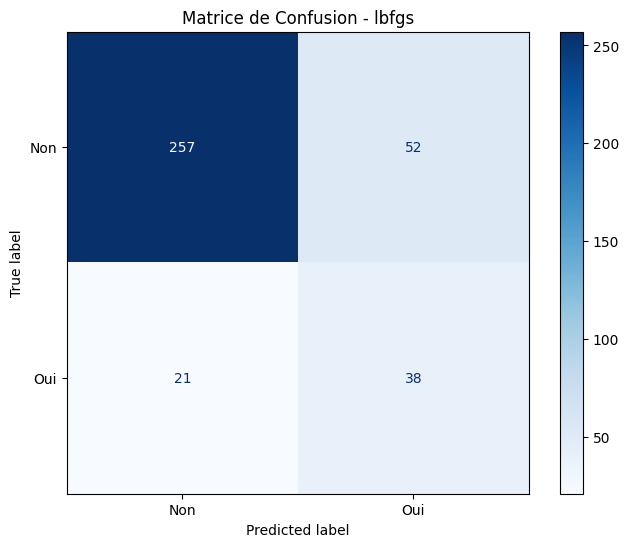

Vrais positifs (TP - Départs détectés): 38
Faux positifs (FP - Fausses alertes): 52
Vrais négatifs (TN - Restés détectés): 257
Faux négatifs (FN - Départs ratés): 21
Rappel (sensibilité): 0.6441
Spécificité: 0.8317



In [44]:
# 1. Prédire sur le Test Set (automatiquement transformé par le pipeline du grid)
# Le SMOTE est automatiquement ignoré lors du .predict() !
y_pred = grid.predict(X_test_avec_f)

# 2. Afficher le rapport de classification (Précision, Recall, F1, F2)
print("--- RAPPORT DE CLASSIFICATION FINAL ---")
print(classification_report(y_test_avec_f, y_pred))

# 3. Générer et afficher la Matrice de Confusion
print("--- MATRICE DE CONFUSION ---")
cm = confusion_matrix(y_test_avec_f, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_enc_avec.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title(f"Matrice de Confusion - {grid.best_params_['classifier__solver']}")
plt.show()

# 4. Détails des erreurs
tn, fp, fn, tp = cm.ravel()
print(f"Vrais positifs (TP - Départs détectés): {tp}")
print(f"Faux positifs (FP - Fausses alertes): {fp}")
print(f"Vrais négatifs (TN - Restés détectés): {tn}")
print(f"Faux négatifs (FN - Départs ratés): {fn}")


# Calculer et afficher les métriques
recall = recall_score(y_test_avec_f, y_pred)
specificity = tn / (tn + fp)

print(f"Rappel (sensibilité): {recall:.4f}")
print(f"Spécificité: {specificity:.4f}")
print()

 #### **1. Les Prédictions Correctes (Le succès)**

* **257 Vrais Négatifs (TN) :** Le modèle a correctement identifié ceux qui restent.
* **38 Vrais Positifs (TP) :** Départs anticipés. Ce sont 38 démissions que les RH peuvent tenter d'éviter.

#### **2. Les Erreurs de Diagnostic (Le risque)**

* **52 Faux Positifs (FP) :** **Fausse alerte.** Le modèle prédit un départ, mais l'employé reste.
* *Impact :* Faible. On mobilise un RH pour un entretien de rétention inutile.


* **21 Faux Négatifs (FN) :** **Alerte.** L'employé part sans que le modèle ne l'ait détecté.
* *Impact :* **Élevé.** C'est une perte de talent imprévue pour l'entreprise.



---

### **Conclusion**

> Le modèle est très performant pour identifier ceux qui sont fidèles à l'entreprise : il affiche 83% de réussite (303 employés restants bien identifiés).

> **La limite :** Il manque d'efficacité sur notre objectif principal : la détection des démissions. Il ne repère que 64% des départs réels, soit seulement 38 alertes réussies sur 59 départs effectifs.

> **Action :** Pour mieux répondre au besoin des RH, nous devons ajuster le seuil de décision pour transformer ces 'Faux Négatifs' en 'Vrais Positifs', quitte à accepter un peu plus de fausses alertes.

# **Optimisation du Seuil de Prédiction (Arbitrage RH)**

Par défaut, le modèle utilise un seuil de **0.5** pour décider si un employé va démissionner. Cependant, ce réglage "neutre" n'est pas forcément adapté aux enjeux de l'entreprise. Modifier ce seuil nous permet de choisir quelle erreur nous voulons minimiser :

#### **1. Le Rappel :**

* **Objectif :** Capter le plus grand nombre de démissions possible.
* **Enjeu :** Éviter les **Faux Négatifs** (les départs surprises). Un Salarié qui part sans avoir été détecté représente un coût élevé pour l'entreprise (recrutement, perte de compétences, désorganisation).

#### **2. La Précision :**

* **Objectif :** S'assurer que chaque alerte déclenchée concerne un employé réellement sur le départ.
* **Enjeu :** Éviter les **Faux Positifs** (les fausses alertes). Trop de fausses alertes risquent de faire perdre du temps aux managers et de décrédibiliser l'outil auprès des RH.

### **Notre stratégie**

L'objectif est d'ajuster ce seuil pour **maximiser le Rappel**.


# **Arbitrage Précision-Rappel : Optimisation du Seuil de Détection**

In [44]:
# Pour obtenir les probabilités (ex: 0.82 au lieu de 1)
y_prob = grid.predict_proba(X_test_avec_f)
y_prob_positive = y_prob[:, 1]     # Pour avoir uniquement la probabilité de départ (classe 1), on fait :

# Liste des seuils
seuils = [0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1, 0.05]
stats = []

for s in seuils:
    preds = (y_prob_positive >= s).astype(int)

    p = precision_score(y_test_avec_f, preds, zero_division=0)
    r = recall_score(y_test_avec_f, preds)
    f2 = fbeta_score(y_test_avec_f, preds, beta=2)

    tn, fp, fn, tp = confusion_matrix(y_test_avec_f, preds).ravel()

    stats.append({
        "Seuil": s,
        "Précision": round(p, 3),
        "Recall (Détection)": round(r, 3),
        "F2-Score (Priorité Recall)": round(f2, 3), # nouvel arbitre
        "Départs ratés (FN)": fn
    })

df_seuils = pd.DataFrame(stats)
print(df_seuils.to_string(index=False))

 Seuil  Précision  Recall (Détection)  F2-Score (Priorité Recall)  Départs ratés (FN)
  0.50      0.422               0.644                       0.583                  21
  0.45      0.385               0.678                       0.588                  19
  0.40      0.356               0.712                       0.593                  17
  0.35      0.341               0.746                       0.603                  15
  0.30      0.314               0.814                       0.617                  11
  0.25      0.294               0.881                       0.630                   7
  0.20      0.254               0.915                       0.601                   5
  0.15      0.233               0.949                       0.588                   3
  0.10      0.210               0.949                       0.557                   3
  0.05      0.182               0.949                       0.515                   3


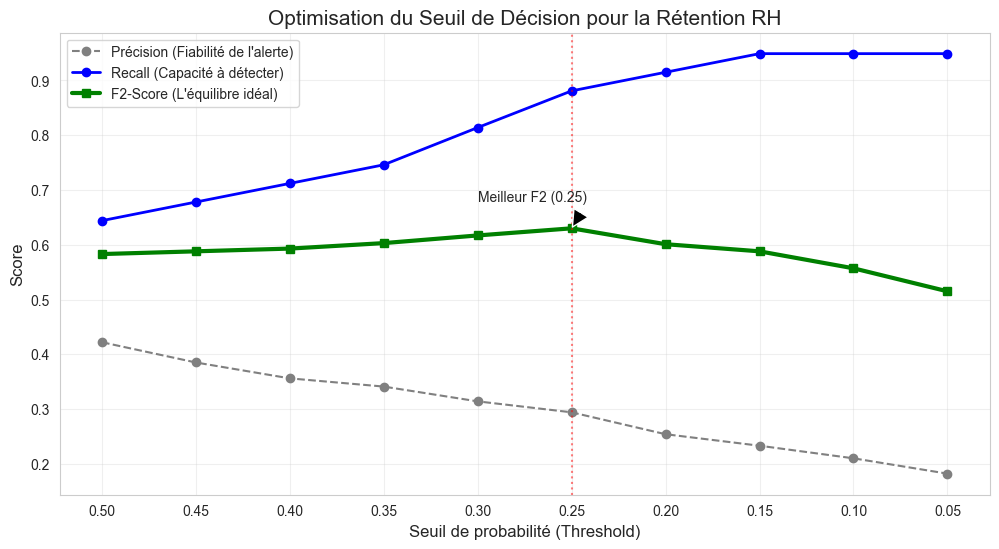

In [45]:

# On prépare le style
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# On trace les trois métriques
plt.plot(df_seuils["Seuil"], df_seuils["Précision"], marker='o', label="Précision (Fiabilité de l'alerte)", linestyle='--', color='gray')
plt.plot(df_seuils["Seuil"], df_seuils["Recall (Détection)"], marker='o', label="Recall (Capacité à détecter)", color='blue', linewidth=2)
plt.plot(df_seuils["Seuil"], df_seuils["F2-Score (Priorité Recall)"], marker='s', label="F2-Score (L'équilibre idéal)", color='green', linewidth=3)

# Mise en forme
plt.title("Optimisation du Seuil de Décision pour la Rétention RH", fontsize=15)
plt.xlabel("Seuil de probabilité (Threshold)", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.xticks(seuils) # Pour voir tous tes seuils sur l'axe X
plt.legend()
plt.gca().invert_xaxis() # Optionnel : inverser l'axe pour voir le recall monter de gauche à droite
plt.grid(True, alpha=0.3)

# Ajouter une zone d'ombre pour le "Best F2"
best_f2_row = df_seuils.loc[df_seuils["F2-Score (Priorité Recall)"].idxmax()]
plt.axvline(best_f2_row["Seuil"], color='red', alpha=0.5, linestyle=':')
plt.annotate(f'Meilleur F2 ({best_f2_row["Seuil"]})',
             xy=(best_f2_row["Seuil"], best_f2_row["F2-Score (Priorité Recall)"]),
             xytext=(best_f2_row["Seuil"]+0.05, best_f2_row["F2-Score (Priorité Recall)"]+0.05),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.show()

# **Interprétabilité du modèle + Aide à la Décision**

### **1. Importance Globale : Identifier les leviers RH**

Les Coefficients (Le moteur du modèle)Avant SHAP, on regarde les poids ($\beta$) de ta Régression Logistique.

* **Les Coefficients du Modéle:** Avant SHAP, on regarde les poids ($\beta$) de nortre Régression Logistique.

* **SHAP Summary Plot (Beeswarm) :** Va plus loin en montrant le **sens** de l'influence.


### **2. Analyse Locale : Préparer l'entretien**

* **Outil :** `shap.plots.waterfall`.
* **Usage :** On analyse un employé spécifique ayant un score de risque élevé.

# **Point Vu Global**

#### **Coef Reg**

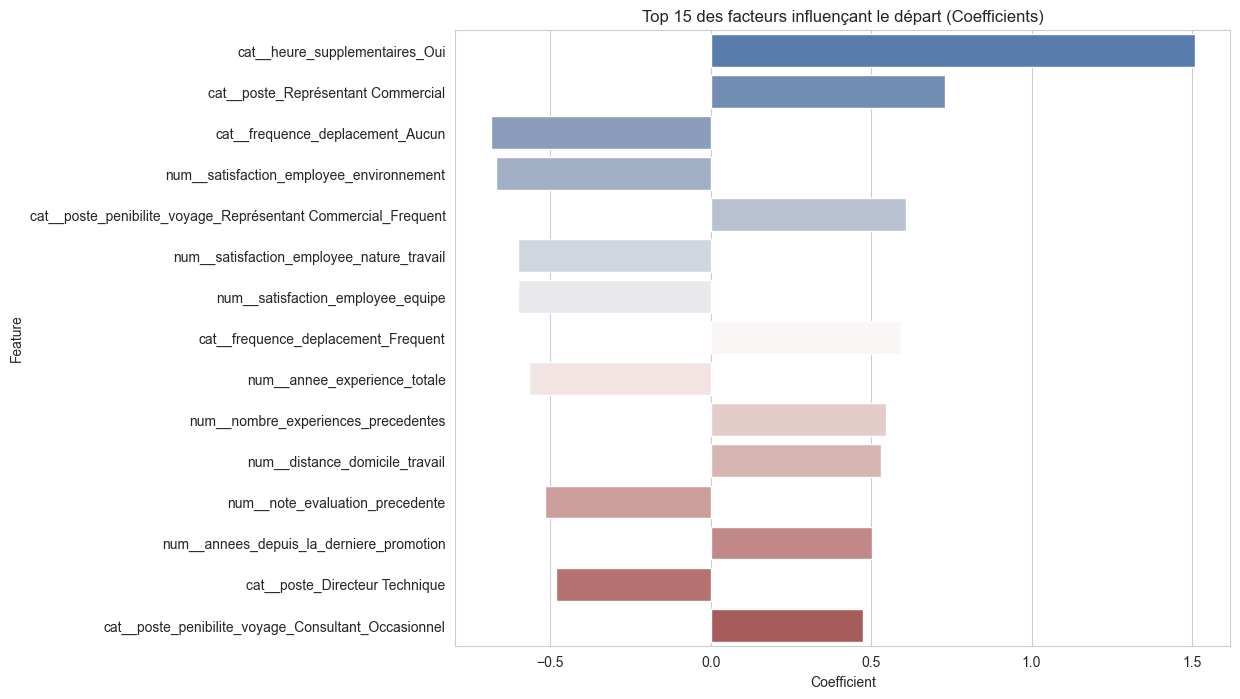

In [46]:
# On récupère le modèle final dans le pipeline du grid
best_model = grid.best_estimator_['classifier']
features = X_train_avec_f.columns

# Création du DataFrame des coefficients
df_importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': best_model.coef_[0]
})

# On calcule l'importance absolue pour le tri
df_importance['Abs_Importance'] = df_importance['Coefficient'].abs()
df_importance = df_importance.sort_values(by='Abs_Importance', ascending=False)

# Affichage
plt.figure(figsize=(10, 8))
sns.barplot(data=df_importance.head(15), x='Coefficient', y='Feature', palette='vlag')
plt.title("Top 15 des facteurs influençant le départ (Coefficients)")
plt.show()



### **1. Les Coefficients du Modèle**

Les coefficients représentent la **pente** (l'importance) que le modèle attribue à chaque variable. C'est la "règle générale" apprise par l'algorithme.

* **Variables à impact positif (Poussent vers le départ) :** Les **heures supplémentaires** et le poste de **Représentant Commercial** dominent. Ce sont les déclencheurs majeurs.
* **Variables à impact négatif (Retiennent l'employé) :** La **satisfaction de l'environnement** et l'**absence de déplacements** agissent comme des ancres de rétention.
* **Variables proches de 0 (La "Zone de Neutralité") :** * Certaines variables comme le **Statut Marital (Divorcé)** ou certains **postes spécifiques (Assistant de Direction)** ont des coefficients très faibles.
   > Cela signifie que ces facteurs n'ont pas de poids systématique sur la décision de partir. Le modèle considère ces informations comme du "bruit" ou des facteurs secondaires qui ne  
   > suffisent pas, à eux seuls, à faire basculer une prédiction.


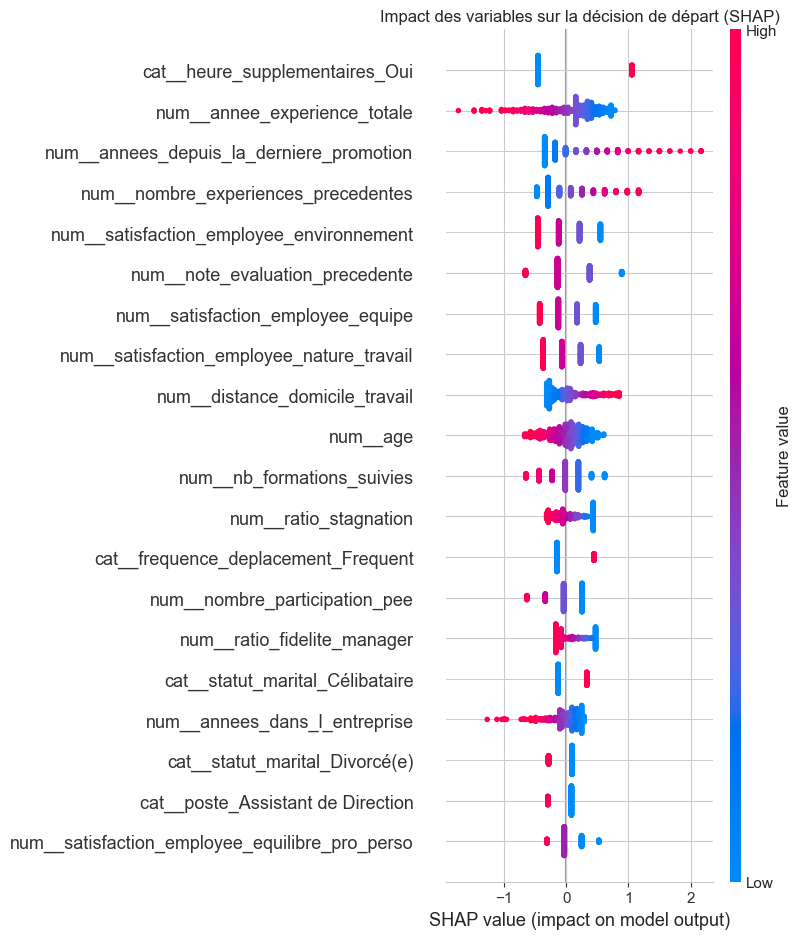

In [47]:
# 1. On récupère le modèle et les données transformées
# Note : SHAP a besoin des données déjà traitées (X_test_avec_f)
explainer = shap.LinearExplainer(grid.best_estimator_.named_steps['classifier'], X_train_avec_f)
shap_values = explainer.shap_values(X_test_avec_f)

# 2. Affichage du résumé global
plt.title("Impact des variables sur la décision de départ (SHAP)")
shap.summary_plot(shap_values, X_test_avec_f)


### **2. SHAP : La Réalité Individuelle (Beeswarm)**

Alors que le coefficient donne un poids fixe, SHAP montre la **distribution** de cet impact sur chaque individu.

* **Effet Déclencheur (Binaire) :** Pour les **heures supp**, c'est tout ou rien. Le passage du bleu (non) au rouge (oui) crée un saut de risque violent et immédiat.
* **Effet de Transition (Numérique) :** Pour l'**âge** ou l'**ancienneté**, les points forment une traînée dégradée. Cela prouve que le risque ne bascule pas d'un coup, mais évolue progressivement avec le temps.
* **Validation :** La concentration des points au centre (0) pour les variables faibles confirme que le modèle est stable et ne sur-réagit pas aux détails inutiles.


### **3. Comparaison et Validation**

* **Cohérence :** Les coefficients et SHAP s'accordent sur les variables de tête. C'est le signe d'un modèle **stable**.
* **Conclusion :** Le modèle a réussi à ignorer les variables non pertinentes (proches de 0) pour se concentrer sur les facteurs de stress réels (travail supplémentaire, pénibilité du métier).



# **Point Vu Local**


CIBLE : TOP CLASSE 0 (Le plus stable)
RÉALITÉ : RESTÉ | PROBABILITÉ DE DÉPART : 0.23%


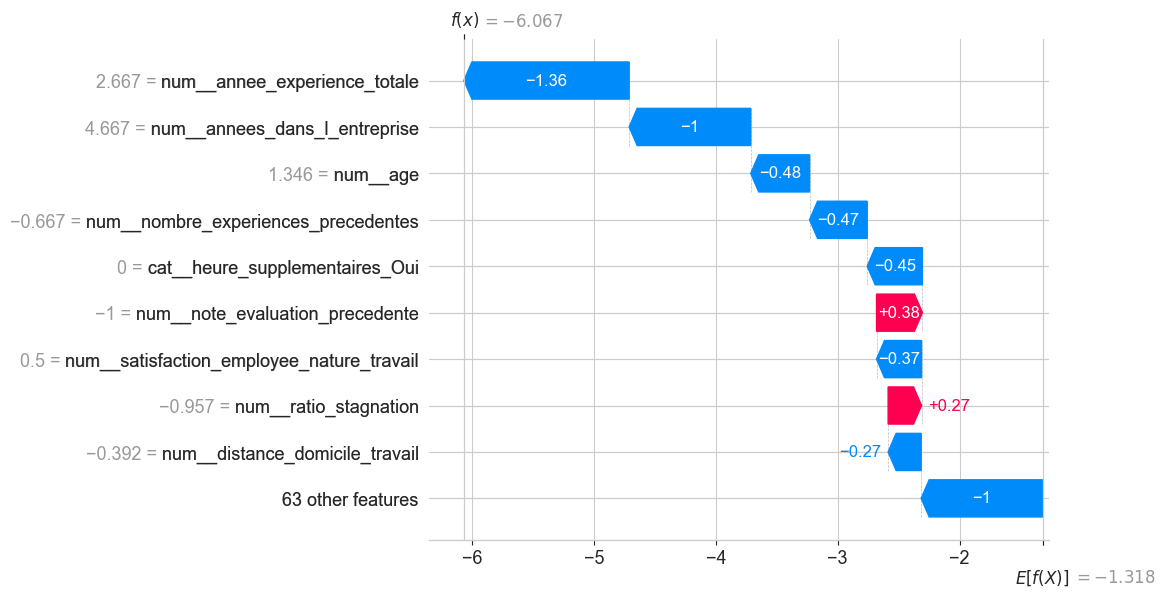


CIBLE : CLASSE 0 (Profil fidèle)
RÉALITÉ : RESTÉ | PROBABILITÉ DE DÉPART : 2.83%


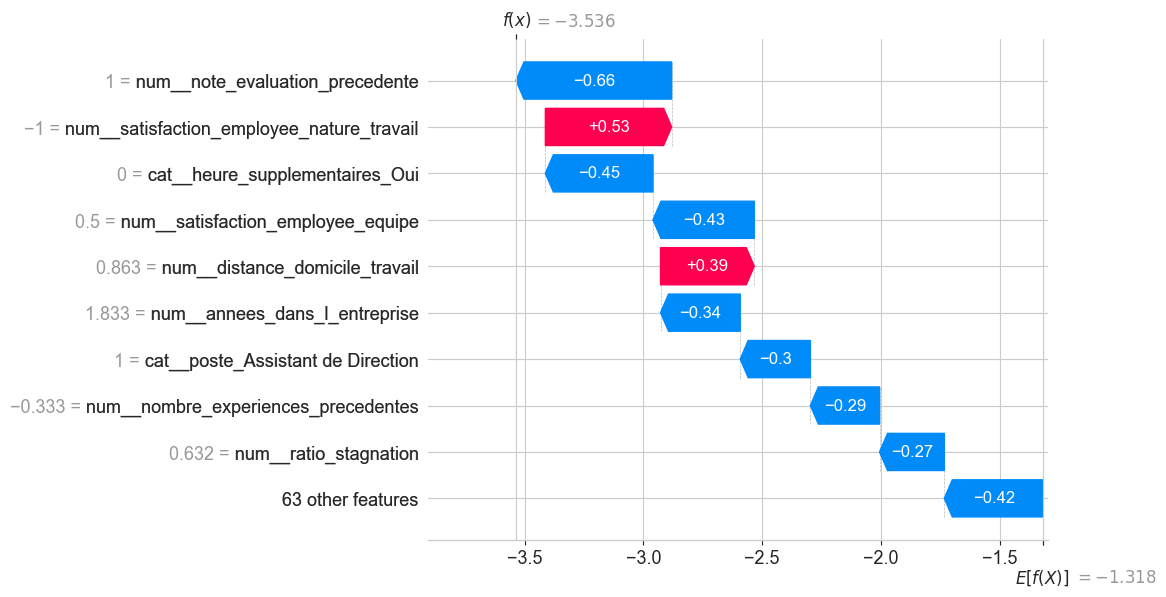


CIBLE : CLASSE 1 (Profil à risque)
RÉALITÉ : RESTÉ | PROBABILITÉ DE DÉPART : 73.74%


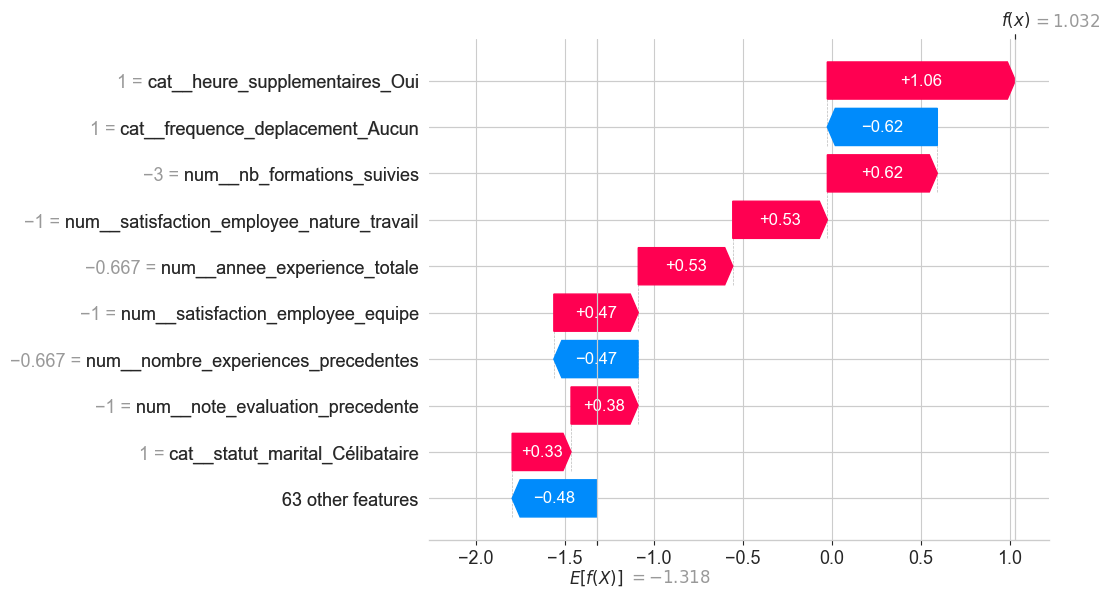


CIBLE : TOP CLASSE 1 (Départ imminent)
RÉALITÉ : RESTÉ | PROBABILITÉ DE DÉPART : 99.08%


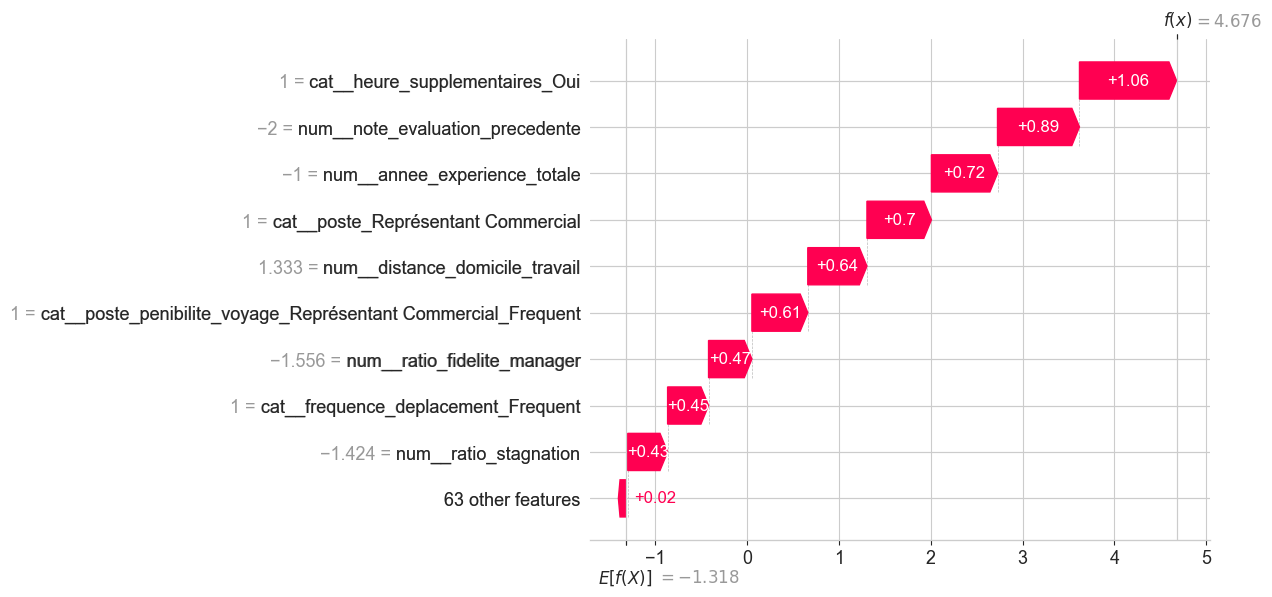

In [48]:
# --- ÉTAPE PRÉALABLE : Création de l'objet exp ---
# On s'assure d'extraire la bonne valeur de base (moyenne) et les bonnes shap_values
base_val = explainer.expected_value[1] if hasattr(explainer.expected_value, "__len__") else explainer.expected_value
shap_vals_classe1 = shap_values[1] if isinstance(shap_values, list) else shap_values

exp = shap.Explanation(
    values=shap_vals_classe1,
    base_values=base_val,
    data=X_test_avec_f.values,
    feature_names=X_test_avec_f.columns.tolist()
)

probs = grid.predict_proba(X_test_avec_f)[:, 1]
y_true = y_test.values

idx_max_0 = np.argmin(probs)
idx_typique_0 = np.argsort(probs)[len(probs)//10]
idx_typique_1 = np.argsort(probs)[-len(probs)//10]
idx_max_1 = np.argmax(probs)

indices = [idx_max_0, idx_typique_0, idx_typique_1, idx_max_1]
titres = ["TOP CLASSE 0 (Le plus stable)", "CLASSE 0 (Profil fidèle)",
          "CLASSE 1 (Profil à risque)", "TOP CLASSE 1 (Départ imminent)"]

for idx, titre in zip(indices, titres):
    statut_reel = "PARTI" if y_true[idx] == 1 else "RESTÉ"

    print(f"\n{'='*60}")
    print(f"CIBLE : {titre}")
    print(f"RÉALITÉ : {statut_reel} | PROBABILITÉ DE DÉPART : {probs[idx]:.2%}")
    print(f"{'='*60}")


    shap.plots.waterfall(exp[idx])


#### **1. Le Profil (Fidélité Maximale)**

* **Score final () : -6.067** (Probabilité de départ quasi nulle).
* On voit que l'expérience totale (-1.36) et l'ancienneté dans l'entreprise (-1.0) sont les deux freins majeurs au départ. Même si cet employé a une légère frustration sur sa note d'évaluation (+0.38), son ancrage historique l'emporte sur tout le reste.

#### **2. Le Profil "Stable mais Vigilant"**

* **Score final () : -3.536** (Profil qui reste, mais avec des signaux mixtes).
* *Ici, c'est la **satisfaction de la nature du travail** qui pose problème (+0.53, en rouge). Cependant, le modèle compense ce risque par une bonne note d'évaluation (-0.66) et le fait que l'employé ne fasse pas d'heures supplémentaires. C'est un profil à surveiller 

#### **3. Le Profil "Bascule" (Risque Émergent)**

* **Score final () : +1.032** (le modèle prédit un départ).
* Le facteur déclencheur est sans appel : **les heures supplémentaires (+1.06)**. C'est l'élément qui fait basculer la décision. On remarque que même si l'employé ne se déplace jamais (-0.62), la fatigue liée au sur-travail et le manque de formations suivies (+0.62) créent un cocktail de désengagement.

#### **4. Le Profil "Alerte Rouge" (Départ Imminent)**

* **Score final () : +4.676** (Certitude de départ quasi totale).
* **Ce qu'il faut retenir :** C'est le cas du "burn-out" ou du ras-le-bol complet. Cumul de tous les facteurs critiques :
* **Surcharge :** Heures supplémentaires (+1.06).
* **Pénibilité :** Poste de commercial avec déplacements fréquents (+0.70 et +0.61).
* **Déséquilibre :** Éloignement géographique (distance domicile-travail +0.64) et mauvaise note d'évaluation (+0.89).
* **Conclusion :** Pour ce profil, toutes les lumières sont rouges. Le modèle identifie une situation de rupture totale.



---

### **Synthèse de ce qu'il en ressort**

* **Le levier universel :** Les **heures supplémentaires** agissent comme l'interrupteur principal du départ. Dès qu'elles apparaissent, elles annulent souvent les bénéfices des autres variables.
* **L'effet protecteur :** L'**ancienneté** (expérience et années dans la boîte) est le meilleur bouclier contre le turnover, agissant comme un stabilisateur émotionnel.
* **L'importance du contexte métier :** On voit clairement que le métier de **Commercial** associé aux **déplacements** crée une zone de danger systématique que le modèle a parfaitement apprise.



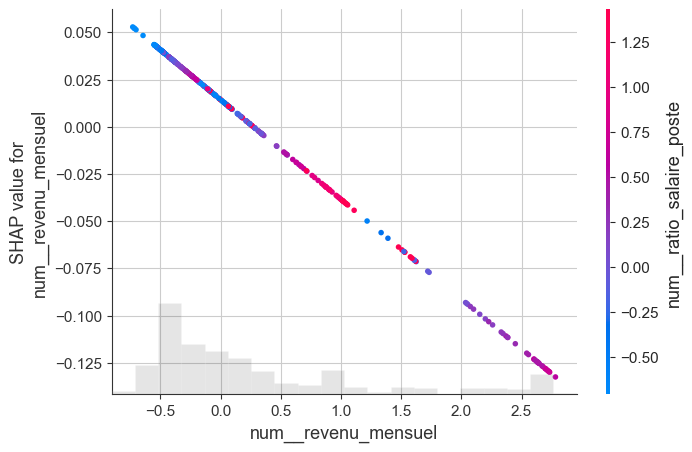

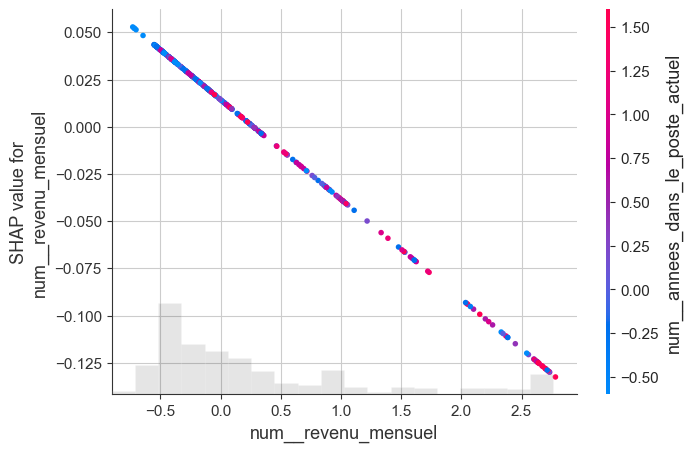

In [49]:

# --- Configuration des index ---
# On récupère les positions exactes dans le tableau
idx_x = X_test_avec_f.columns.get_loc("num__revenu_mensuel")
idx_color = X_test_avec_f.columns.get_loc('num__annees_dans_le_poste_actuel')

# --- Graphique 1 : Impact du revenu seul ---
# SHAP choisira lui-même la variable d'interaction la plus pertinente par défaut
shap.plots.scatter(exp[:, idx_x], color=exp)

# --- Graphique 2 : Impact du revenu + Années dans le poste ---
# Ici on force l'interaction pour voir si l'ancienneté change l'effet du salaire
shap.plots.scatter(exp[:, idx_x], color=exp[:, idx_color])

# **💾 Sauvegarde du modèle pour l'API**

On assemble le `pré-traitement (prepro_avec)` et le meilleur modèle issu de la`GridSearch (grid.best_estimator_)` dans un seul objet.

In [ ]:
# Prtétraitement utilsié

prepro_avec

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

In [ ]:
# On récupère le meilleur estimateur trouvé par la GridSearch
best_reg_model = grid.best_estimator_
best_reg_model

,steps,"[('smote', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False


In [57]:
## Création d'un fichier 

os.makedirs('models')

In [60]:
# On crée l'assemblage final pour la production

pipeline_final_complet = ImbPipeline([
    ('preprocessor', prepro_avec),  # Étape 1 : Nettoyage/Transformation
    ('regresseur', best_reg_model)  # Étape 2 : Prédiction
])


# On sauvegarde l'ensemble dans dossier models pour API 
joblib.dump(pipeline_final_complet, 'models/model_final_reg.joblib')

['models/model_final_reg.joblib']

### TEST

In [63]:

# On recharger le fichier qu'on vient de créer
model_test = joblib.load('models/model_final_reg.joblib')


data_test = X_feature_eng.iloc[0:1] # On prend juste la première ligne pour tester

# On demande une prédiction
prediction = model_test.predict(data_test)
probabilite = model_test.predict_proba(data_test)

print(f" Chargement réussi !")
print(f"Résultat du test : {'Départ' if prediction[0] == 1 else 'Reste'}")
print(f"Probabilités [Reste, Départ] : {probabilite[0]}")

 Chargement réussi !
Résultat du test : Départ
Probabilités [Reste, Départ] : [0.06953486 0.93046514]


In [69]:
# À lancer dans ton notebook
print(list(X_feature_eng.columns))

['age', 'genre', 'revenu_mensuel', 'statut_marital', 'poste', 'nombre_experiences_precedentes', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel', 'satisfaction_employee_environnement', 'note_evaluation_precedente', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'heure_supplementaires', 'augmentation_precedente_salaire_pct', 'nombre_participation_pee', 'nb_formations_suivies', 'distance_domicile_travail', 'niveau_education', 'domaine_etude', 'frequence_deplacement', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel', 'ratio_salaire_poste', 'ratio_stagnation', 'poste_penibilite_voyage', 'attente_promotion_pure', 'ratio_fidelite_manager']


In [66]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

X_feature_eng.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 29 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   age                                        1470 non-null   int64  
 1   genre                                      1470 non-null   str    
 2   revenu_mensuel                             1470 non-null   int64  
 3   statut_marital                             1470 non-null   str    
 4   poste                                      1470 non-null   str    
 5   nombre_experiences_precedentes             1470 non-null   int64  
 6   annee_experience_totale                    1470 non-null   int64  
 7   annees_dans_l_entreprise                   1470 non-null   int64  
 8   annees_dans_le_poste_actuel                1470 non-null   int64  
 9   satisfaction_employee_environnement        1470 non-null   int64  
 10  note_evaluation_precedente         

In [45]:
X_feature_eng.dtypes


age                                            int64
genre                                            str
revenu_mensuel                                 int64
statut_marital                                   str
poste                                            str
nombre_experiences_precedentes                 int64
annee_experience_totale                        int64
annees_dans_l_entreprise                       int64
annees_dans_le_poste_actuel                    int64
satisfaction_employee_environnement            int64
note_evaluation_precedente                     int64
satisfaction_employee_nature_travail           int64
satisfaction_employee_equipe                   int64
satisfaction_employee_equilibre_pro_perso      int64
heure_supplementaires                            str
augmentation_precedente_salaire_pct          float64
nombre_participation_pee                       int64
nb_formations_suivies                          int64
distance_domicile_travail                     

In [129]:
X_feature_eng.iloc[0]


age                                                                    41
genre                                                                   F
revenu_mensuel                                                       5993
statut_marital                                                Célibataire
poste                                                    Cadre Commercial
nombre_experiences_precedentes                                          8
annee_experience_totale                                                 8
annees_dans_l_entreprise                                                6
annees_dans_le_poste_actuel                                             4
satisfaction_employee_environnement                                     2
note_evaluation_precedente                                              3
satisfaction_employee_nature_travail                                    4
satisfaction_employee_equipe                                            1
satisfaction_employee_equilibre_pro_pe

In [75]:
data_quali.columns

Index(['genre', 'statut_marital', 'poste', 'heure_supplementaires',
       'domaine_etude', 'frequence_deplacement', 'poste_penibilite_voyage'],
      dtype='str')

In [81]:
X_feature_eng['frequence_deplacement'].value_counts()

frequence_deplacement
Occasionnel    1043
Frequent        277
Aucun           150
Name: count, dtype: int64

In [77]:
# 1. On définit d'abord la liste des colonnes
col_quali = X_feature_eng.select_dtypes(include=["object"]).columns

# 2. Ensuite, on lance la boucle
for col in col_quali:
    print(f"Colonne : {col}")
    print(X_feature_eng[col].unique())
    print("-" * 30) # Une petite ligne pour séparer visuellement

Colonne : genre
<StringArray>
['F', 'M']
Length: 2, dtype: str
------------------------------
Colonne : statut_marital
<StringArray>
['Célibataire', 'Marié(e)', 'Divorcé(e)']
Length: 3, dtype: str
------------------------------
Colonne : poste
<StringArray>
[       'Cadre Commercial',  'Assistant de Direction',
              'Consultant',               'Tech Lead',
                 'Manager',          'Senior Manager',
 'Représentant Commercial',     'Directeur Technique',
     'Ressources Humaines']
Length: 9, dtype: str
------------------------------
Colonne : heure_supplementaires
<StringArray>
['Oui', 'Non']
Length: 2, dtype: str
------------------------------
Colonne : domaine_etude
<StringArray>
[          'Infra & Cloud',                   'Autre',
 'Transformation Digitale',               'Marketing',
         'Entrepreunariat',     'Ressources Humaines']
Length: 6, dtype: str
------------------------------
Colonne : frequence_deplacement
<StringArray>
['Occasionnel', 'Frequent

In [60]:
data_quali['genre'].unique()

<StringArray>
['F', 'M']
Length: 2, dtype: str

In [128]:
data_quali = X_feature_eng[col]
data_quali.shape

(1470,)

In [83]:
data_test

NameError: name 'data_test' is not defined

In [94]:
X_feature_eng.columns

Index(['age', 'genre', 'revenu_mensuel', 'statut_marital', 'poste',
       'nombre_experiences_precedentes', 'annee_experience_totale',
       'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel',
       'satisfaction_employee_environnement', 'note_evaluation_precedente',
       'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'heure_supplementaires',
       'augmentation_precedente_salaire_pct', 'nombre_participation_pee',
       'nb_formations_suivies', 'distance_domicile_travail',
       'niveau_education', 'domaine_etude', 'frequence_deplacement',
       'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel',
       'ratio_salaire_poste', 'ratio_stagnation', 'poste_penibilite_voyage',
       'attente_promotion_pure', 'ratio_fidelite_manager'],
      dtype='str')

In [ ]:
annees_dans_l_entreprise	annees_dans_le_poste_actuel	

In [99]:
print(X_feature_eng['heure_supplementaires'].unique())

<StringArray>
['Oui', 'Non']
Length: 2, dtype: str


In [107]:
condition_1 = X_feature_eng["revenu_mensuel"] < X_feature_eng["revenu_mensuel"].median()
condition_2 = X_feature_eng["age"] < 35
condition_3 = X_feature_eng['heure_supplementaires'] =="oui"

# Utilisation de & et des parenthèses
resulta = X_feature_eng.loc[(condition_1) | (condition_2) | (condition_3), :]
resulta

,age,genre,revenu_mensuel,statut_marital,poste,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,...,niveau_education,domaine_etude,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,ratio_salaire_poste,ratio_stagnation,poste_penibilite_voyage,attente_promotion_pure,ratio_fidelite_manager
2,37,M,2090,Célibataire,Consultant,6,7,0,0,4,...,2,Autre,Occasionnel,0,0,0.645626,0.000000,Consultant_Occasionnel,0,0.000000
3,33,F,2909,Marié(e),Assistant de Direction,1,8,8,7,4,...,4,Infra & Cloud,Frequent,3,0,0.897847,0.864198,Assistant de Direction_Frequent,4,0.000000
4,27,M,3468,Marié(e),Consultant,9,6,2,2,1,...,1,Transformation Digitale,Occasionnel,2,2,1.071306,0.952381,Consultant_Occasionnel,0,0.952381
5,32,M,3068,Célibataire,Consultant,0,8,7,7,4,...,2,Infra & Cloud,Frequent,3,6,0.947741,0.985915,Consultant_Frequent,4,0.845070
6,59,F,2670,Marié(e),Consultant,4,12,1,0,3,...,3,Transformation Digitale,Occasionnel,0,0,0.824795,0.000000,Consultant_Occasionnel,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1463,31,M,9936,Célibataire,Tech Lead,0,10,9,4,2,...,3,Transformation Digitale,Aucun,1,7,1.362003,0.439560,Tech Lead_Aucun,3,1.100000
1464,26,F,2966,Célibataire,Représentant Commercial,0,5,4,2,4,...,3,Autre,Occasionnel,0,0,1.129474,0.487805,Représentant Commercial_Occasionnel,2,0.000000
1465,36,M,2571,Marié(e),Consultant,4,17,5,2,3,...,2,Transformation Digitale,Frequent,0,3,0.794212,0.392157,Consultant_Frequent,2,1.100000
1467,27,M,6142,Marié(e),Tech Lead,1,6,6,2,2,...,3,Infra & Cloud,Occasionnel,0,3,0.841931,0.327869,Tech Lead_Occasionnel,2,1.100000


In [126]:
X_feature_eng[X_feature_eng['heure_supplementaires'] =="non"]

,age,genre,revenu_mensuel,statut_marital,poste,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,...,niveau_education,domaine_etude,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,ratio_salaire_poste,ratio_stagnation,poste_penibilite_voyage,attente_promotion_pure,ratio_fidelite_manager


In [ ]:
ligne 2,5,1465   profil risque

ligne 3,4,36    deplacement

80, 85, 61      bonne statifaction 

In [113]:
# La bonne méthode pour plusieurs valeurs
critere_voyageur = X_feature_eng["satisfaction_employee_environnement"] ==4 

# On applique le filtre
X_feature_eng.loc[critere_voyageur, ['age', 'genre', 'statut_marital', 'poste', 'frequence_deplacement', 'satisfaction_employee_environnement']].head(40)

,age,genre,statut_marital,poste,frequence_deplacement,satisfaction_employee_environnement
2,37,M,Célibataire,Consultant,Occasionnel,4
3,33,F,Marié(e),Assistant de Direction,Frequent,4
5,32,M,Célibataire,Consultant,Frequent,4
7,30,M,Divorcé(e),Consultant,Occasionnel,4
8,38,M,Célibataire,Tech Lead,Frequent,4
11,29,F,Célibataire,Consultant,Occasionnel,4
17,22,M,Divorcé(e),Consultant,Aucun,4
19,38,M,Célibataire,Assistant de Direction,Occasionnel,4
31,44,M,Marié(e),Manager,Occasionnel,4
32,30,M,Célibataire,Consultant,Occasionnel,4


In [ ]:
age_min= X_feature_eng[X_feature_eng["age"] == X_feature_eng["age"].min()]
age_max= X_feature_eng[X_feature_eng["age"] == X_feature_eng["age"].max()]


ligne 2,5,1465   profil risque

ligne 3,4,36    deplacement

80, 85, 61      bonne statifaction 

In [118]:
age_min

,age,genre,revenu_mensuel,statut_marital,poste,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,...,niveau_education,domaine_etude,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,ratio_salaire_poste,ratio_stagnation,poste_penibilite_voyage,attente_promotion_pure,ratio_fidelite_manager
296,18,M,1420,Célibataire,Consultant,1,0,0,0,3,...,3,Infra & Cloud,Occasionnel,0,0,0.438655,0.0,Consultant_Occasionnel,0,0.0
301,18,F,1200,Célibataire,Représentant Commercial,1,0,0,0,4,...,3,Transformation Digitale,Occasionnel,0,0,0.456969,0.0,Représentant Commercial_Occasionnel,0,0.0
457,18,M,1878,Célibataire,Représentant Commercial,1,0,0,0,2,...,3,Marketing,Frequent,0,0,0.715156,0.0,Représentant Commercial_Frequent,0,0.0
727,18,M,1051,Célibataire,Assistant de Direction,1,0,0,0,2,...,2,Infra & Cloud,Aucun,0,0,0.324385,0.0,Assistant de Direction_Aucun,0,0.0
828,18,M,1904,Célibataire,Consultant,1,0,0,0,3,...,1,Transformation Digitale,Aucun,0,0,0.588168,0.0,Consultant_Aucun,0,0.0
972,18,F,1611,Célibataire,Consultant,1,0,0,0,4,...,3,Infra & Cloud,Aucun,0,0,0.497657,0.0,Consultant_Aucun,0,0.0
1153,18,F,1569,Célibataire,Représentant Commercial,1,0,0,0,2,...,2,Transformation Digitale,Frequent,0,0,0.597487,0.0,Représentant Commercial_Frequent,0,0.0
1311,18,F,1514,Célibataire,Assistant de Direction,1,0,0,0,2,...,3,Transformation Digitale,Aucun,0,0,0.467288,0.0,Assistant de Direction_Aucun,0,0.0


In [115]:
test_data = X_feature_eng.iloc[[2, 5, 1465, 3, 4, 36, 80, 85, 61]]
test_data

,age,genre,revenu_mensuel,statut_marital,poste,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,...,niveau_education,domaine_etude,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,ratio_salaire_poste,ratio_stagnation,poste_penibilite_voyage,attente_promotion_pure,ratio_fidelite_manager
2,37,M,2090,Célibataire,Consultant,6,7,0,0,4,...,2,Autre,Occasionnel,0,0,0.645626,0.000000,Consultant_Occasionnel,0,0.000000
5,32,M,3068,Célibataire,Consultant,0,8,7,7,4,...,2,Infra & Cloud,Frequent,3,6,0.947741,0.985915,Consultant_Frequent,4,0.845070
1465,36,M,2571,Marié(e),Consultant,4,17,5,2,3,...,2,Transformation Digitale,Frequent,0,3,0.794212,0.392157,Consultant_Frequent,2,1.100000
3,33,F,2909,Marié(e),Assistant de Direction,1,8,8,7,4,...,4,Infra & Cloud,Frequent,3,0,0.897847,0.864198,Assistant de Direction_Frequent,4,0.000000
4,27,M,3468,Marié(e),Consultant,9,6,2,2,1,...,1,Transformation Digitale,Occasionnel,2,2,1.071306,0.952381,Consultant_Occasionnel,0,0.952381
36,50,M,2683,Marié(e),Représentant Commercial,1,3,3,2,1,...,2,Marketing,Occasionnel,0,2,1.021706,0.645161,Représentant Commercial_Occasionnel,2,0.952381
80,30,M,5126,Marié(e),Consultant,1,10,10,8,4,...,1,Infra & Cloud,Occasionnel,3,0,1.583482,0.792079,Consultant_Occasionnel,5,0.000000
85,56,M,7260,Célibataire,Tech Lead,4,37,6,4,4,...,3,Infra & Cloud,Occasionnel,0,2,0.995183,0.655738,Tech Lead_Occasionnel,4,0.487805
61,38,F,2406,Célibataire,Consultant,1,10,10,3,4,...,5,Infra & Cloud,Frequent,9,9,0.743242,0.297030,Consultant_Frequent,0,1.100000


In [130]:
X_train_sans_f.loc[[2, 5, 1465, 3, 4, 36, 80, 85, 61], "heure_supplementaires"]

KeyError: 'heure_supplementaires'

In [132]:
X_train_sans_f.columns

Index(['num__age', 'num__revenu_mensuel',
       'num__nombre_experiences_precedentes', 'num__annee_experience_totale',
       'num__annees_dans_l_entreprise', 'num__annees_dans_le_poste_actuel',
       'num__satisfaction_employee_environnement',
       'num__note_evaluation_precedente',
       'num__satisfaction_employee_nature_travail',
       'num__satisfaction_employee_equipe',
       'num__satisfaction_employee_equilibre_pro_perso',
       'num__augmentation_precedente_salaire_pct',
       'num__nombre_participation_pee', 'num__nb_formations_suivies',
       'num__distance_domicile_travail', 'num__niveau_education',
       'num__annees_depuis_la_derniere_promotion',
       'num__annes_sous_responsable_actuel', 'cat__genre_M',
       'cat__statut_marital_Célibataire', 'cat__statut_marital_Divorcé(e)',
       'cat__statut_marital_Marié(e)', 'cat__poste_Assistant de Direction',
       'cat__poste_Cadre Commercial', 'cat__poste_Consultant',
       'cat__poste_Directeur Technique', 'ca

In [119]:
# Utilisation de orient='records' pour avoir une liste de dictionnaires
# force_ascii=False est crucial ici pour garder les accents comme dans "Marié(e)"
X_feature_eng.iloc[[2, 5, 1465, 3, 4, 36, 80, 85, 61]].to_json(
    'api_data.json', 
    orient='records', 
    indent=4, 
    force_ascii=False
)

In [137]:
df_central.loc[[2, 5, 1465, 3, 4, 36, 80, 85, 61], ["age","heure_supplementaires"]]

,age,heure_supplementaires
2,37,Oui
5,32,Non
1465,36,Non
3,33,Oui
4,27,Non
36,50,Oui
80,30,Oui
85,56,Non
61,38,Non
